### **Exploratory Data Analysis**

In [1]:
from ast import increment_lineno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize']=(10,5) # runtime configuration parameters
plt.rcParams['figure.dpi']=300 #resolution dots per inches
%matplotlib inline
#after plotting fraph, many timesb depending on version of working library like matplotlib graph will not be displayed on the output screen below
#for that we have to write every time plt.show()
#so if u write %matplotlin inline we dont need to write show() method
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("/content/data_clean1.csv")
df

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,NaN,NaN,14.3,5,5,2010,56,S
...,...,...,...,...,...,...,...,...
153,41.0,190.0,7.4,5,1,2010,67,C
154,30.0,193.0,6.9,9,26,2010,70,PS
155,NaN,145.0,13.2,9,27,2010,77,S
156,14.0,191.0,14.3,9,28,2010,75,S


In [3]:
df.head()

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,NaN,NaN,14.3,5,5,2010,56,S


In [4]:
df.tail()

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
153,41.0,190.0,7.4,5,1,2010,67,C
154,30.0,193.0,6.9,9,26,2010,70,PS
155,NaN,145.0,13.2,9,27,2010,77,S
156,14.0,191.0,14.3,9,28,2010,75,S
157,18.0,131.0,8.0,9,29,2010,76,C


In [5]:
df.describe()
# positive skewness is there in ozone as mean is greater than median i.e, 41.58 > 30.50 so the outliers are present on upper extreame part
#year values same fopr all values so year column is not imp here.

,Ozone,Solar.R,Wind,Day,Year,Temp
count,120.000000,151.000000,158.000000,158.000000,158.0,158.000000
mean,41.583333,185.403974,9.957595,16.006329,2010.0,77.727848
std,32.620709,88.723103,3.511261,8.997166,0.0,9.377877
min,1.000000,7.000000,1.700000,1.000000,2010.0,56.000000
25%,18.000000,119.000000,7.400000,8.000000,2010.0,72.000000
50%,30.500000,197.000000,9.700000,16.000000,2010.0,78.500000
75%,61.500000,257.000000,11.875000,24.000000,2010.0,84.000000
max,168.000000,334.000000,20.700000,31.000000,2010.0,97.000000


In [6]:
df.describe(include='object')

,Month,Weather
count,158,155
unique,6,3
top,9,S
freq,34,59


In [7]:
df.dtypes

,0
Ozone,float64
Solar.R,float64
Wind,float64
Month,object
Day,int64
Year,int64
Temp,int64
Weather,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    120 non-null    float64
 1   Solar.R  151 non-null    float64
 2   Wind     158 non-null    float64
 3   Month    158 non-null    object 
 4   Day      158 non-null    int64  
 5   Year     158 non-null    int64  
 6   Temp     158 non-null    int64  
 7   Weather  155 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 10.0+ KB


In [9]:
df['Month']

,Month
0,5
1,5
2,5
3,5
4,5
...,...
153,5
154,9
155,9
156,9


In [10]:
df['Month'].unique()

array(['5', 'May', '6', '7', '8', '9'], dtype=object)

In [11]:
df['Month'].value_counts()

,count
Month,
9,34
5,31
7,31
8,31
6,30
May,1


In [12]:
df["Month"].replace("May","5",inplace=True)

In [13]:
df['Month'].unique()

array(['5', '6', '7', '8', '9'], dtype=object)

In [14]:
df.dtypes

,0
Ozone,float64
Solar.R,float64
Wind,float64
Month,object
Day,int64
Year,int64
Temp,int64
Weather,object


In [15]:
df["Month"].astype(int)

,Month
0,5
1,5
2,5
3,5
4,5
...,...
153,5
154,9
155,9
156,9


In [16]:
df["Month"]= df["Month"].astype(int)

In [ ]:
df.dtypes

,0
Ozone,float64
Solar.R,float64
Wind,float64
Month,int64
Day,int64
Year,int64
Temp,int64
Weather,object


# **Duplicates**

In [17]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
153,False
154,False
155,False
156,True


In [18]:
df.duplicated().sum()

1

In [ ]:
#print duplicated values. keep=(first,last,false), keep= first record as original and rest as duplicate
#default for keep in first . keep=false will treat all similar records as duplicate
df[df.duplicated()]


,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
156,14.0,191.0,14.3,9,28,2010,75,S


In [19]:
df[df.duplicated(keep=False)]

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
150,14.0,191.0,14.3,9,28,2010,75,S
156,14.0,191.0,14.3,9,28,2010,75,S


In [20]:
# Drop duplicated records
df.drop_duplicates(inplace=True)
df.shape

(157, 8)

In [ ]:
df.duplicated().sum()

0

# Drop columns

In [21]:
df.head(10)

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,NaN,NaN,14.3,5,5,2010,56,S
5,28.0,NaN,14.9,5,6,2010,66,C
6,23.0,299.0,8.6,5,7,2010,65,PS
7,19.0,99.0,13.8,5,8,2010,59,C
8,8.0,19.0,20.1,5,9,2010,61,PS
9,NaN,194.0,8.6,5,10,2010,69,S


In [22]:
df.tail(10)

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
147,14.0,20.0,16.6,9,25,2010,63,PS
148,30.0,193.0,6.9,9,26,2010,70,C
149,NaN,145.0,13.2,9,27,2010,77,PS
150,14.0,191.0,14.3,9,28,2010,75,S
151,18.0,131.0,8.0,9,29,2010,76,PS
152,20.0,223.0,11.5,9,30,2010,68,S
153,41.0,190.0,7.4,5,1,2010,67,C
154,30.0,193.0,6.9,9,26,2010,70,PS
155,NaN,145.0,13.2,9,27,2010,77,S
157,18.0,131.0,8.0,9,29,2010,76,C


In [23]:
df.drop(columns=["Year"],inplace=True )
# To delete multiple columns
# df.drop(columns=["Year","Ozone"],inplace=True )

In [24]:
df.head()

,Ozone,Solar.R,Wind,Month,Day,Temp,Weather
0,41.0,190.0,7.4,5,1,67,S
1,36.0,118.0,8.0,5,2,72,C
2,12.0,149.0,12.6,5,3,74,PS
3,18.0,313.0,11.5,5,4,62,S
4,NaN,NaN,14.3,5,5,56,S


In [25]:
# to drop a record or row
df.drop(index=[1])
#df.drop(index=[1,3])

,Ozone,Solar.R,Wind,Month,Day,Temp,Weather
0,41.0,190.0,7.4,5,1,67,S
2,12.0,149.0,12.6,5,3,74,PS
3,18.0,313.0,11.5,5,4,62,S
4,NaN,NaN,14.3,5,5,56,S
5,28.0,NaN,14.9,5,6,66,C
...,...,...,...,...,...,...,...
152,20.0,223.0,11.5,9,30,68,S
153,41.0,190.0,7.4,5,1,67,C
154,30.0,193.0,6.9,9,26,70,PS
155,NaN,145.0,13.2,9,27,77,S


# Rename the columns

In [26]:
df.head()

,Ozone,Solar.R,Wind,Month,Day,Temp,Weather
0,41.0,190.0,7.4,5,1,67,S
1,36.0,118.0,8.0,5,2,72,C
2,12.0,149.0,12.6,5,3,74,PS
3,18.0,313.0,11.5,5,4,62,S
4,NaN,NaN,14.3,5,5,56,S


In [27]:
#rename the solar column, pass parameter in dictionary form
df.rename(columns={"Solar.R":"Solar","Temp":"Temparature"},inplace=True)
df

,Ozone,Solar,Wind,Month,Day,Temparature,Weather
0,41.0,190.0,7.4,5,1,67,S
1,36.0,118.0,8.0,5,2,72,C
2,12.0,149.0,12.6,5,3,74,PS
3,18.0,313.0,11.5,5,4,62,S
4,NaN,NaN,14.3,5,5,56,S
...,...,...,...,...,...,...,...
152,20.0,223.0,11.5,9,30,68,S
153,41.0,190.0,7.4,5,1,67,C
154,30.0,193.0,6.9,9,26,70,PS
155,NaN,145.0,13.2,9,27,77,S


#** Missing value Imputation**
Reasons for misssin values:
*  data entry errors
*  issues with machines
*  improper data handling

Treatment:
*   0 to 5% missing values: drops rows
*   6 to 45% replace the missing values
*   50% drop column





In [28]:
df.head()

,Ozone,Solar,Wind,Month,Day,Temparature,Weather
0,41.0,190.0,7.4,5,1,67,S
1,36.0,118.0,8.0,5,2,72,C
2,12.0,149.0,12.6,5,3,74,PS
3,18.0,313.0,11.5,5,4,62,S
4,NaN,NaN,14.3,5,5,56,S


In [29]:
df.isna() # or isnull(), True:missing value

,Ozone,Solar,Wind,Month,Day,Temparature,Weather
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...
152,False,False,False,False,False,False,False
153,False,False,False,False,False,False,False
154,False,False,False,False,False,False,False
155,True,False,False,False,False,False,False


In [30]:
df.isna().sum()

,0
Ozone,38
Solar,7
Wind,0
Month,0
Day,0
Temparature,0
Weather,3


In [31]:
df.isnull().sum()

,0
Ozone,38
Solar,7
Wind,0
Month,0
Day,0
Temparature,0
Weather,3


<Axes: >

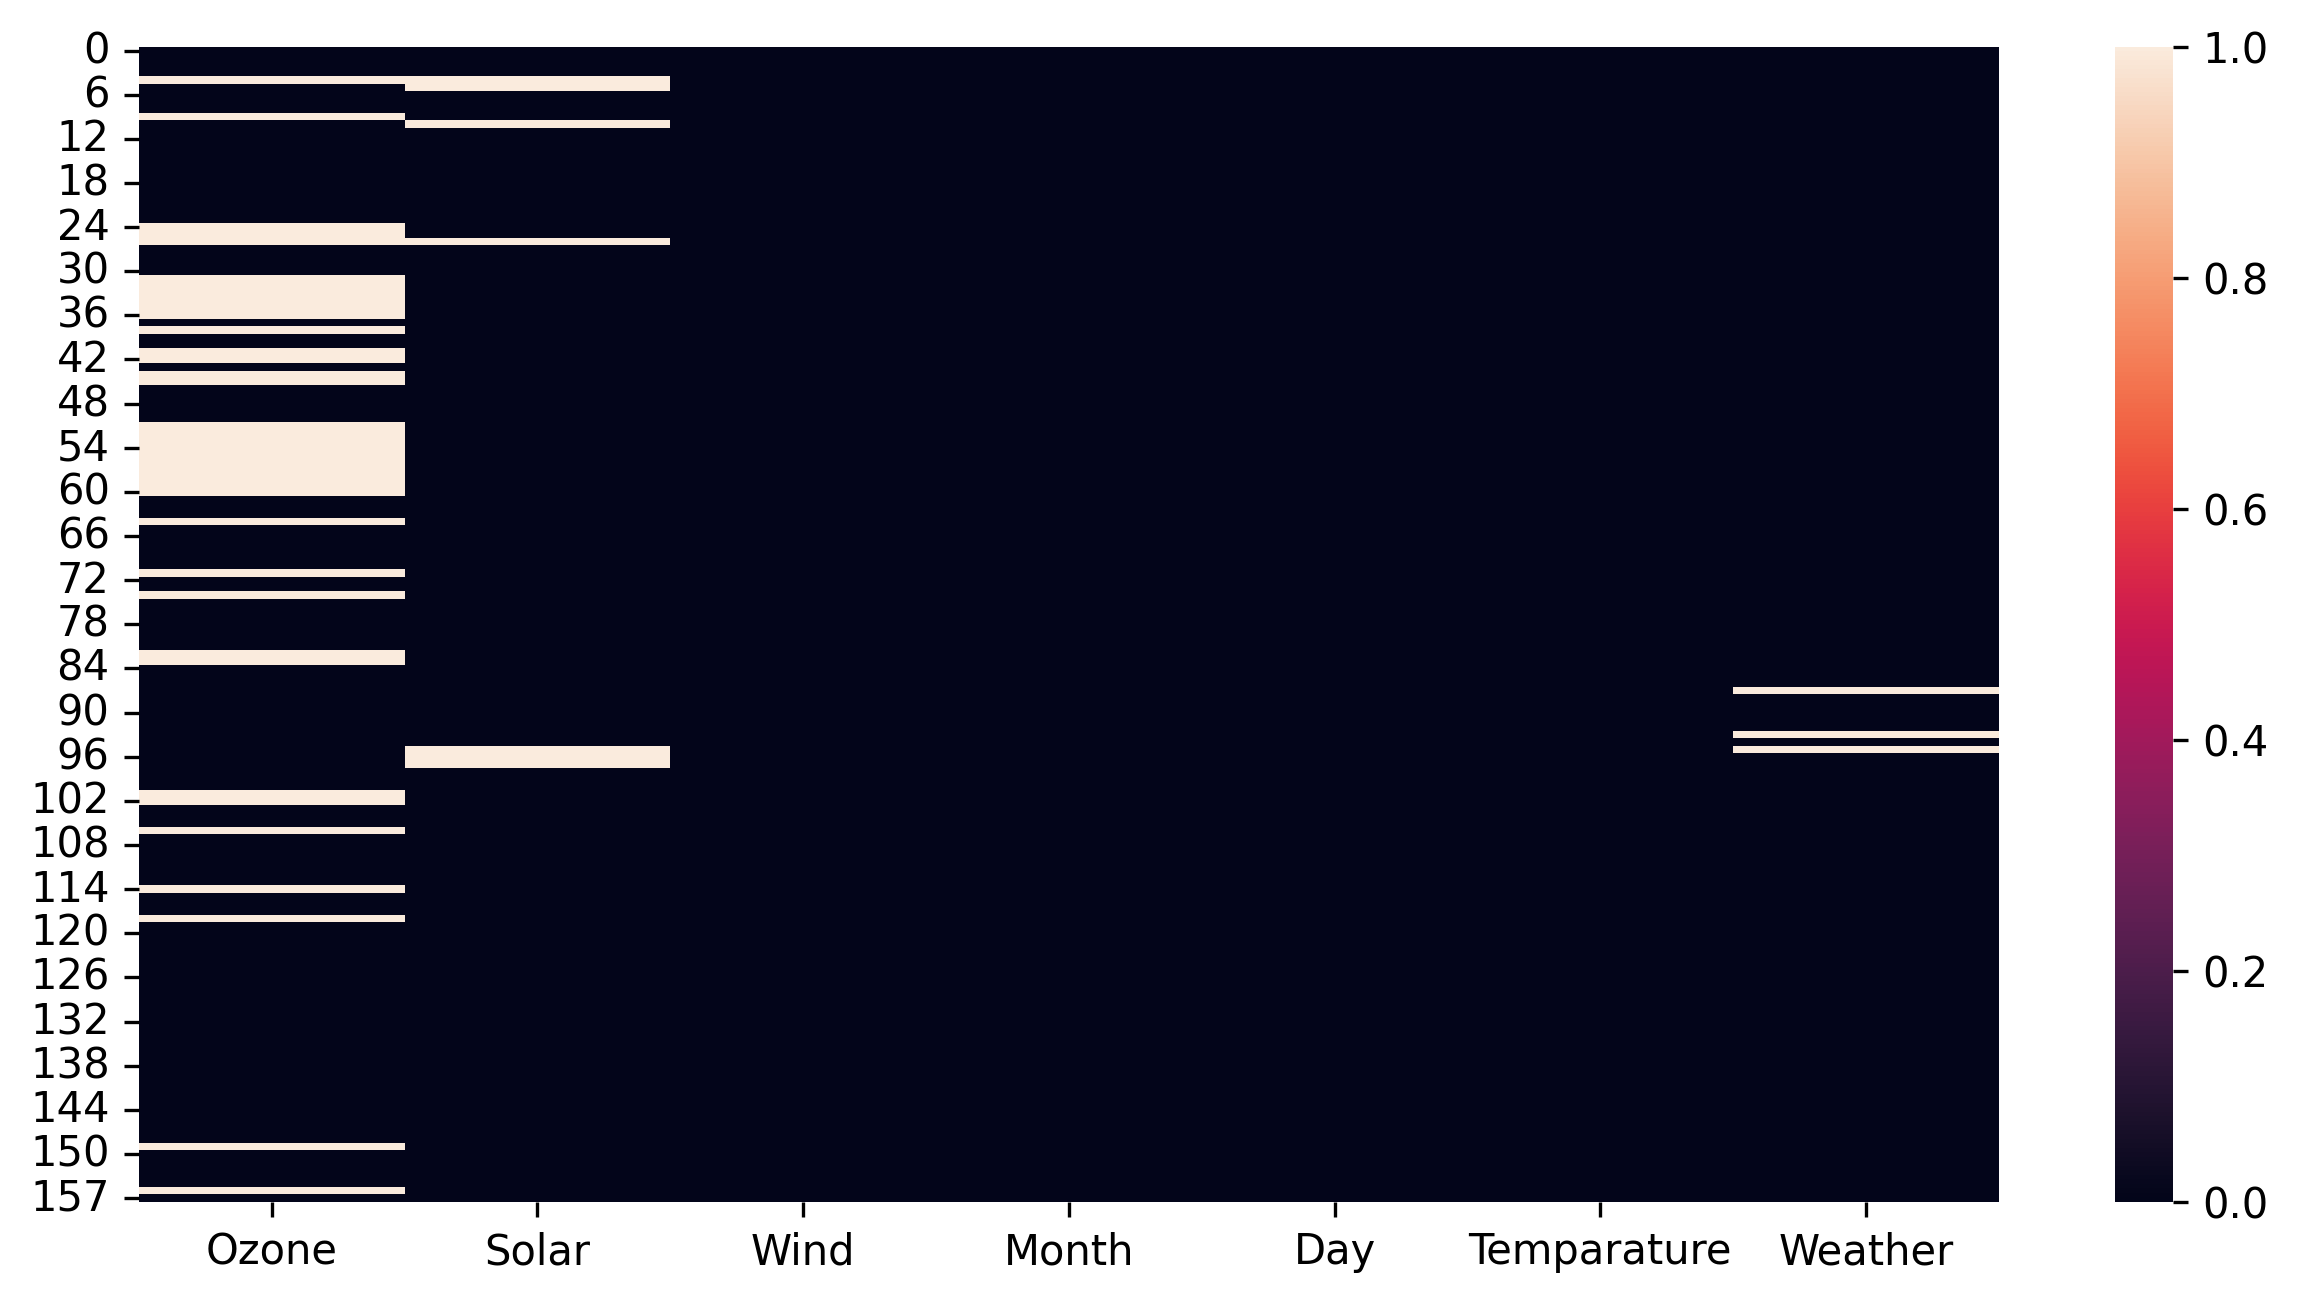

In [32]:
#visualize missing values
sns.heatmap(df.isna()) # white horizontal lines are missing values

In [33]:
len(df)

157

In [37]:
# % of missing values
for i in df.isna().sum():
  print(i/len(df)*100)

#Ozone: replace missing values as missing values are in the range of 6 to 45%
#Solar,whether: drop missing values
# but we will trat missing values
#Ozone and solar are numeric columns. if the outliers are present in that column,replace missing value by Median
#if no outliers in column replace missing value with mean
# if categorical column replace missing value with mode.


24.203821656050955
4.45859872611465
0.0
0.0
0.0
0.0
1.910828025477707


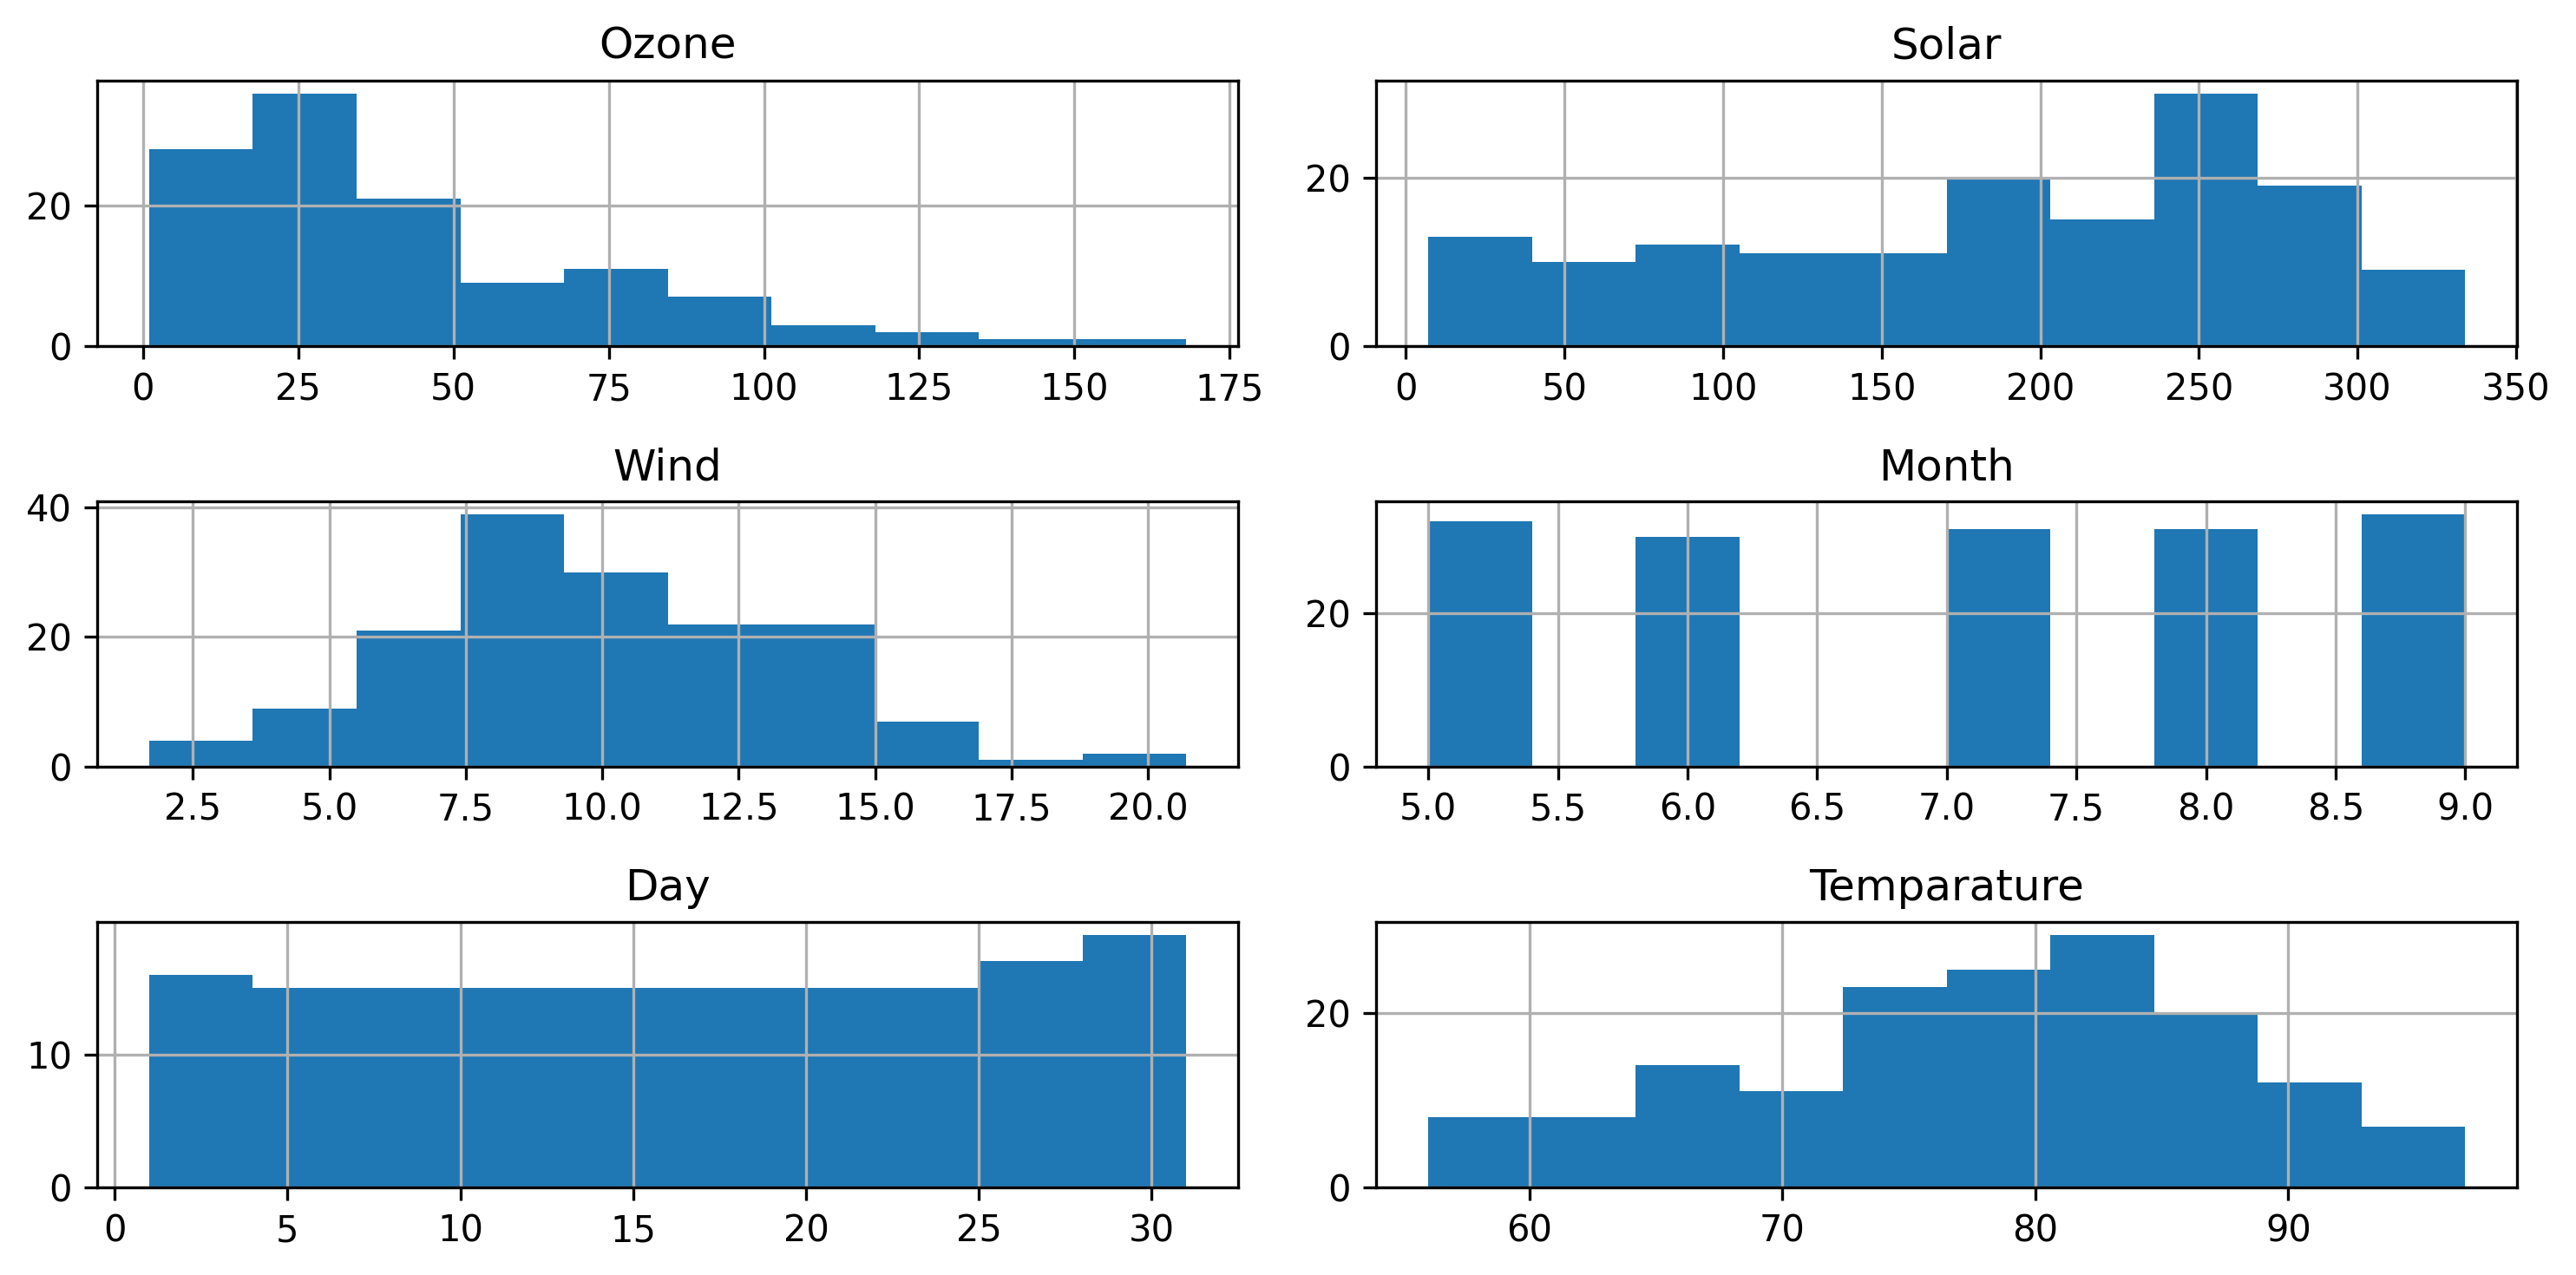

In [38]:
df.hist()
plt.tight_layout() # avoid overlapping of labels of graphs
# Skewness: less than -1 or grater than +1 high skewness
#-0.5 to +0.5 :moderate skewness
#0: normal

<Axes: >

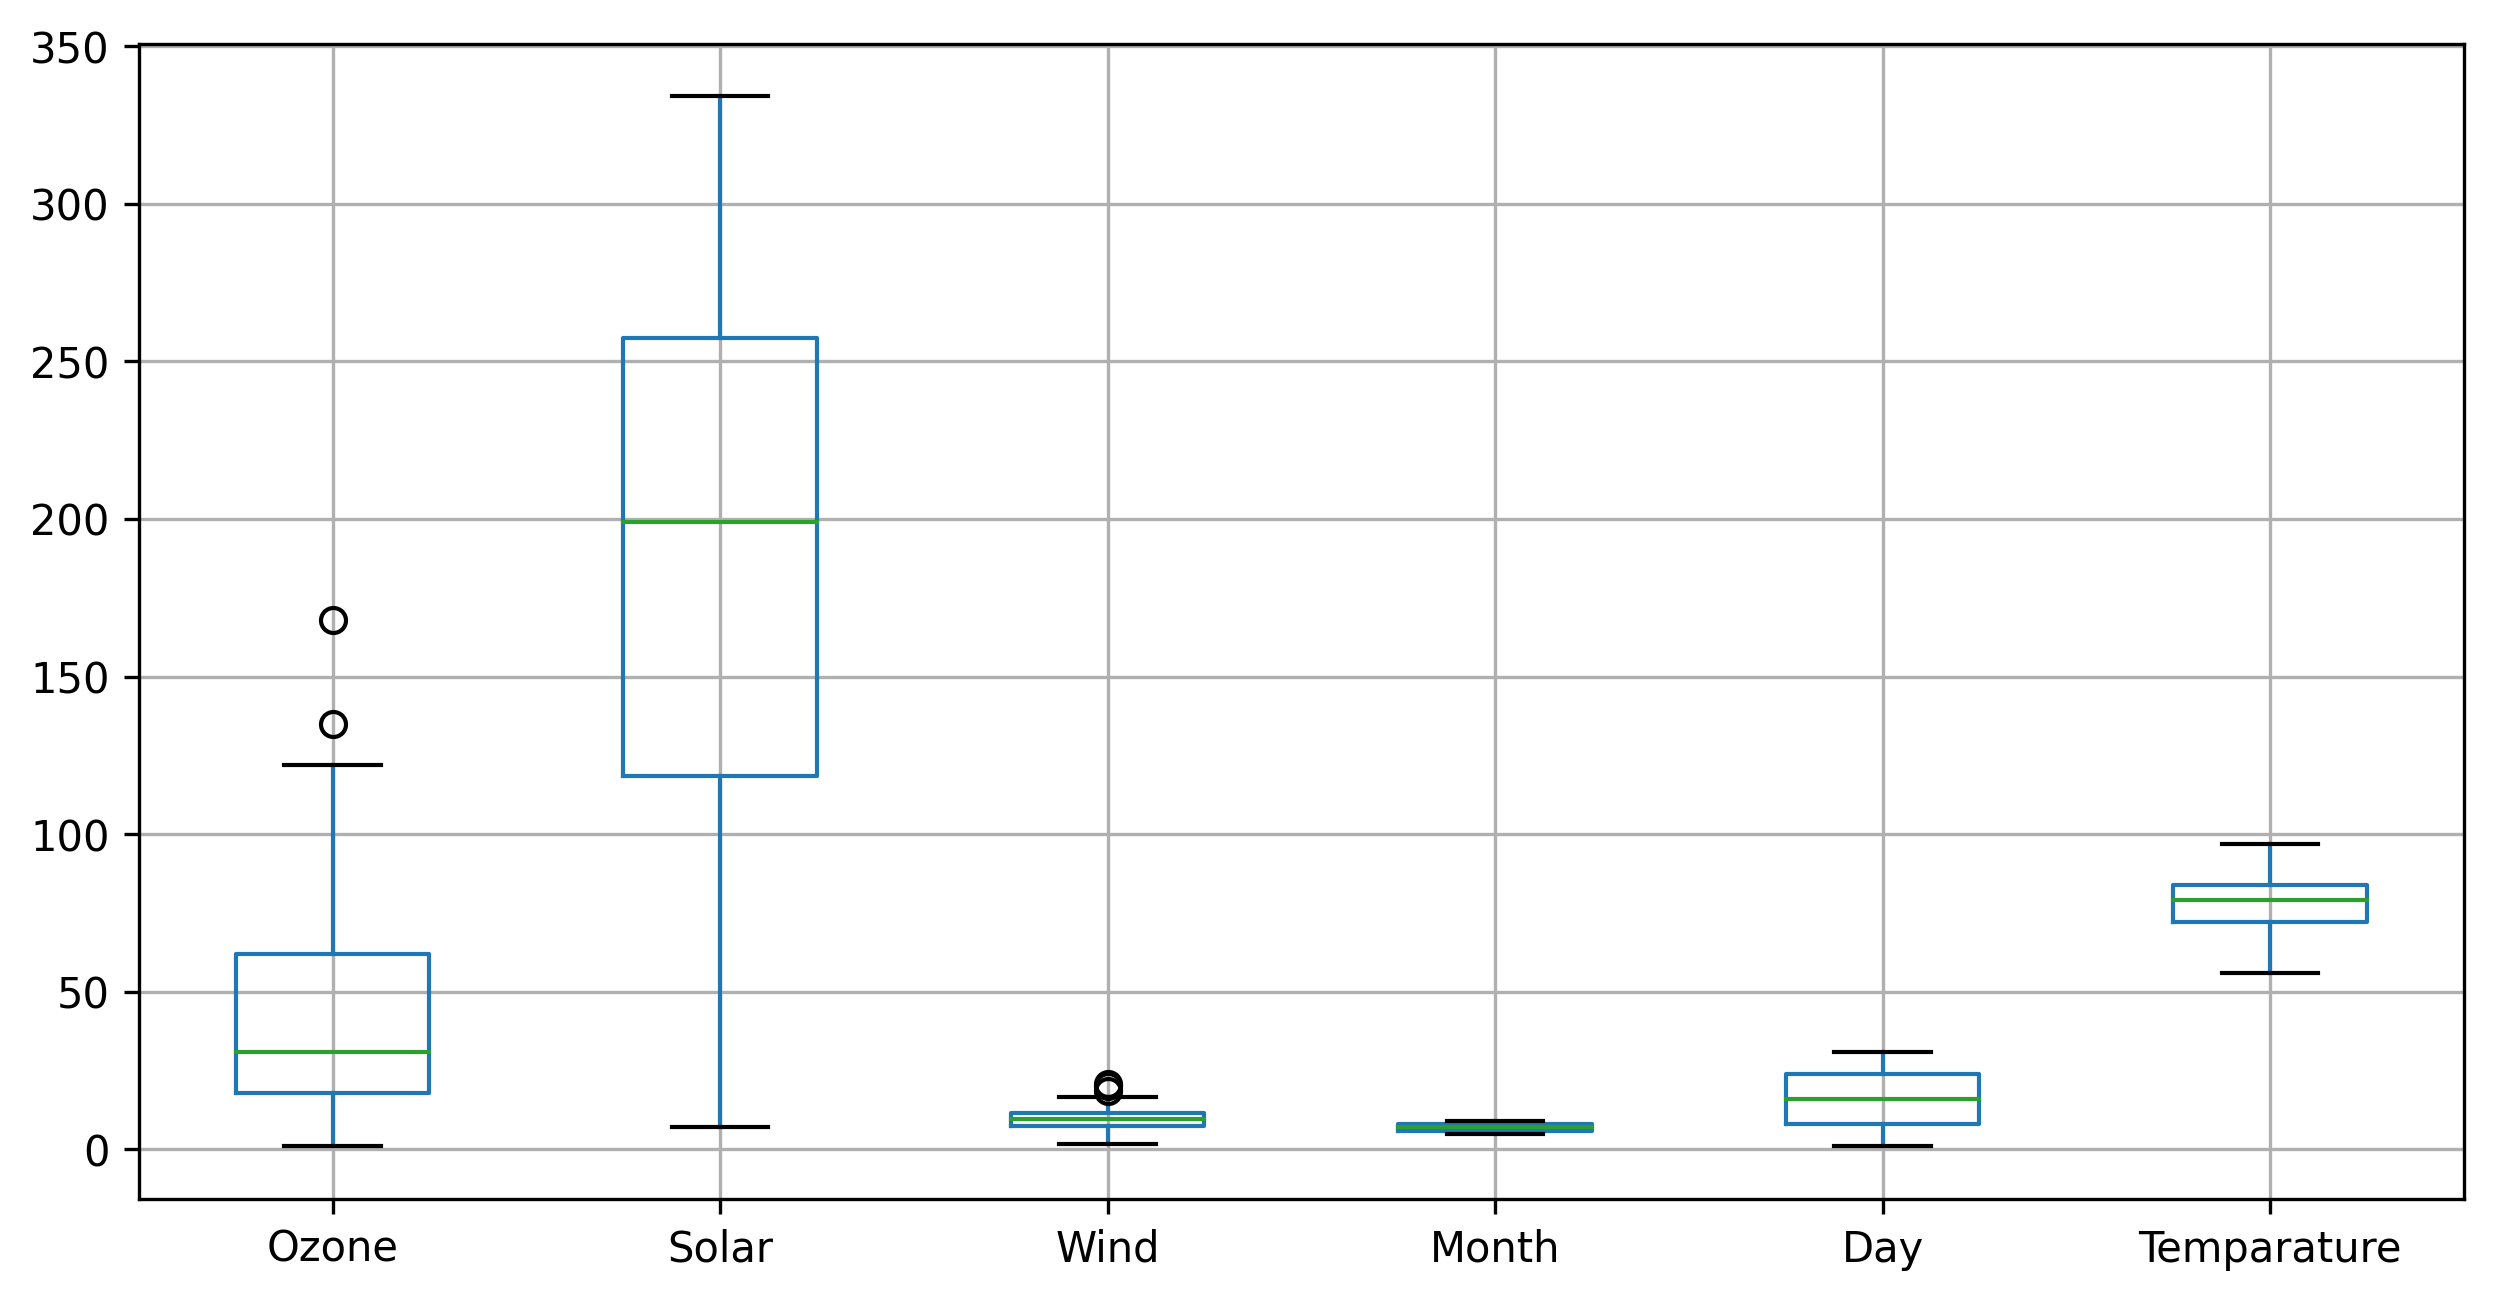

In [39]:
df.boxplot()
# Ozone: outliers are present so replace missing values with median
# in solar :No outliers so replace missing values by mean

<Axes: xlabel='Wind'>

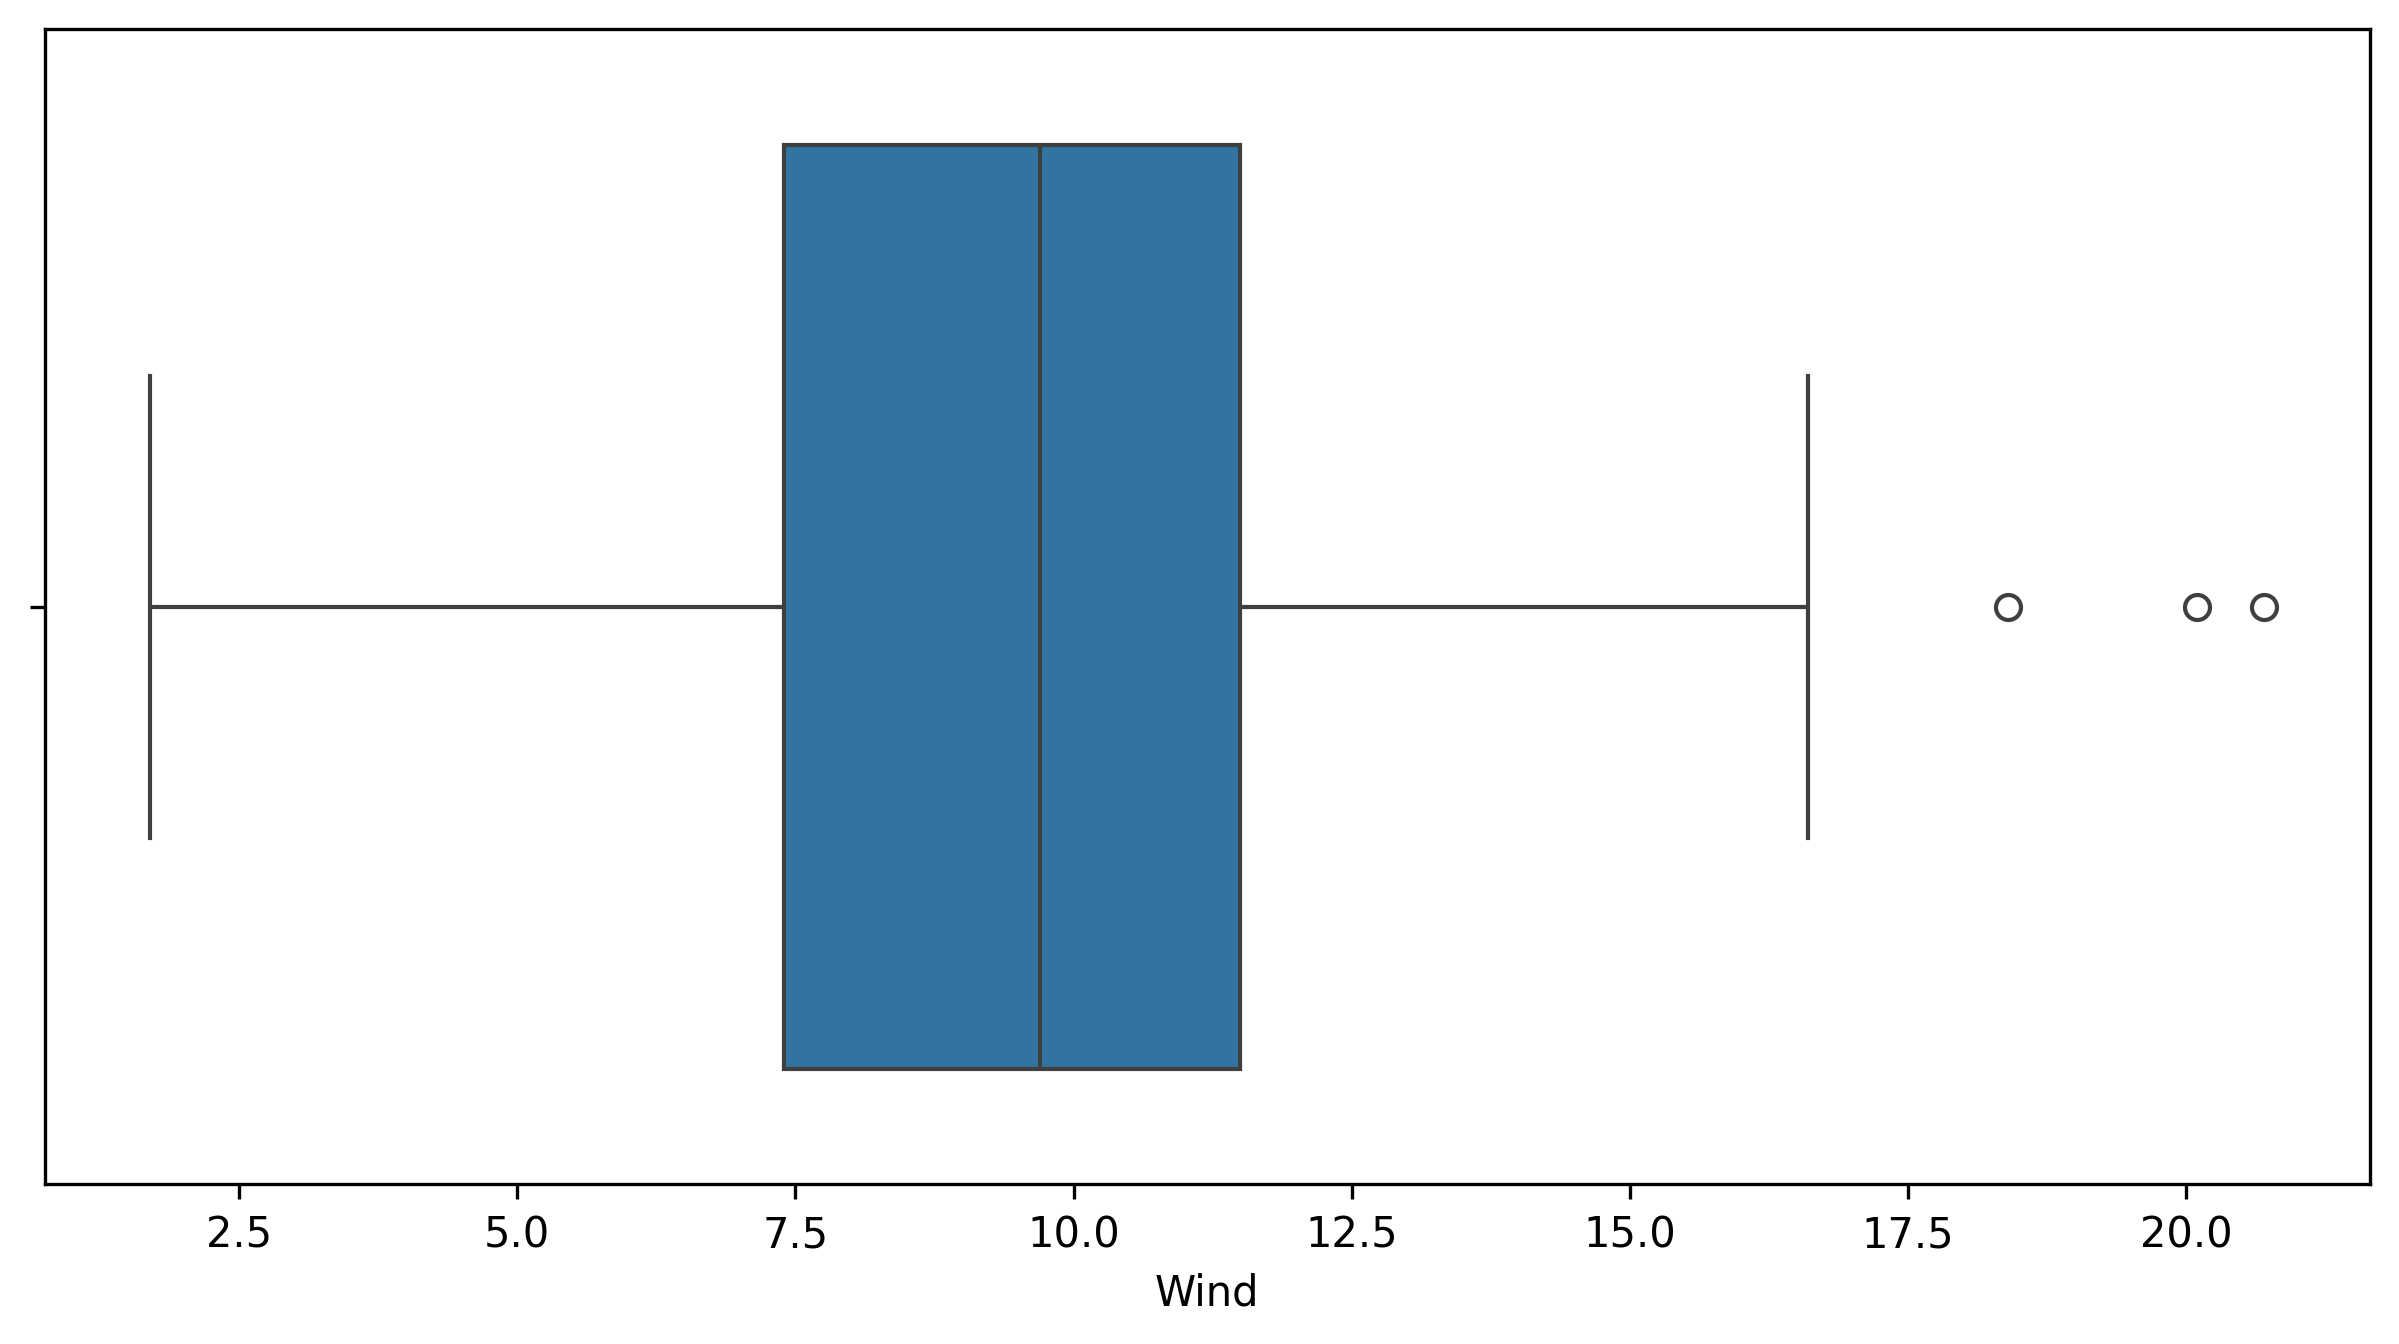

In [40]:
sns.boxplot(x=df["Wind"])

In [50]:
Ozone_median=df["Ozone"].median()
Ozone_median

31.0

In [51]:
df["Ozone"].fillna(Ozone_median,inplace=True)

In [52]:
df.isna().sum()

,0
Ozone,0
Solar,0
Wind,0
Month,0
Day,0
Temparature,0
Weather,3


In [53]:
solar_mean=df["Solar"].mean()
solar_mean

185.36666666666667

In [54]:
df["Solar"].fillna(solar_mean,inplace=True)

In [55]:
df.isna().sum()

,0
Ozone,0
Solar,0
Wind,0
Month,0
Day,0
Temparature,0
Weather,3


In [56]:
df["Weather"].value_counts()

,count
Weather,
S,58
C,49
PS,47


In [57]:
weather_mode=df["Weather"].mode()
weather_mode

,Weather
0,S


In [58]:
weather_mode=df["Weather"].mode()[0]
weather_mode

'S'

In [59]:
df["Weather"].fillna(weather_mode,inplace=True)

In [60]:
df.isna().sum()

,0
Ozone,0
Solar,0
Wind,0
Month,0
Day,0
Temparature,0
Weather,0


In [ ]:
df["Weather"].value_counts()

,count
Weather,
S,61
C,49
PS,47


# Outliers Detection


*   Histogram
*   Box plot
*   Descritive Statistics





In [61]:
df.describe()

,Ozone,Solar,Wind,Month,Day,Temparature
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,39.197452,185.366667,9.929936,7.019108,15.929936,77.745223
std,28.781992,86.998999,3.505188,1.434338,8.974404,9.405334
min,1.000000,7.000000,1.700000,5.000000,1.000000,56.000000
25%,21.000000,127.000000,7.400000,6.000000,8.000000,72.000000
50%,31.000000,193.000000,9.700000,7.000000,16.000000,79.000000
75%,45.000000,255.000000,11.500000,8.000000,24.000000,84.000000
max,168.000000,334.000000,20.700000,9.000000,31.000000,97.000000


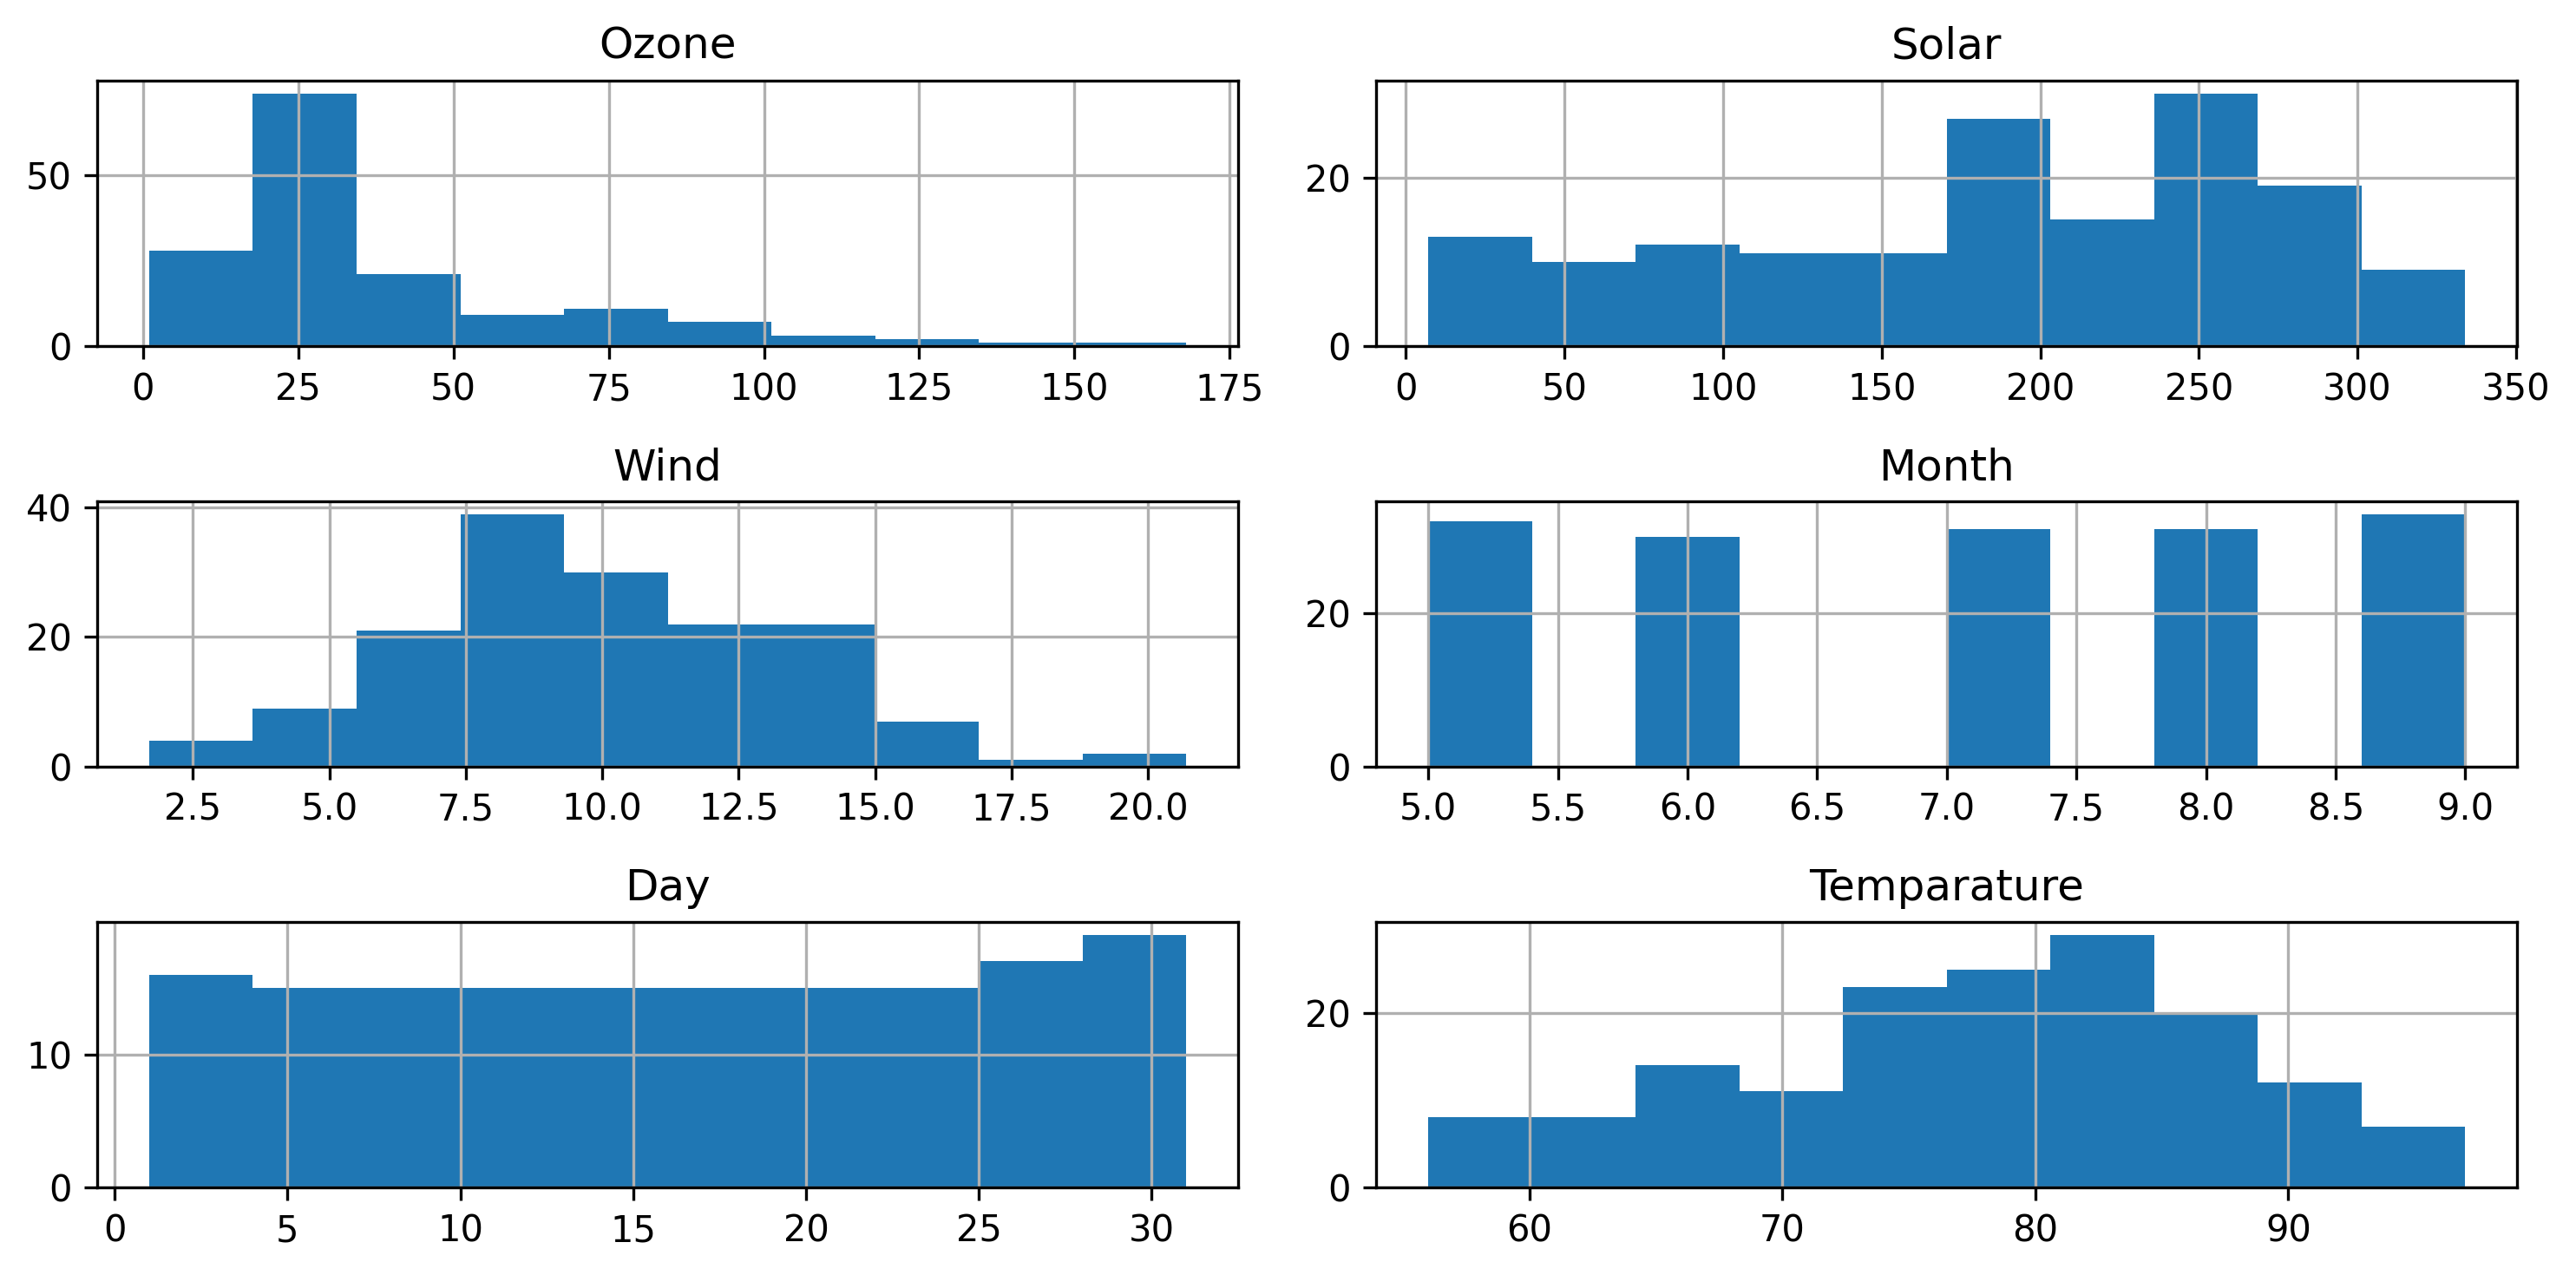

In [62]:
df.hist()
plt.tight_layout()

<Axes: >

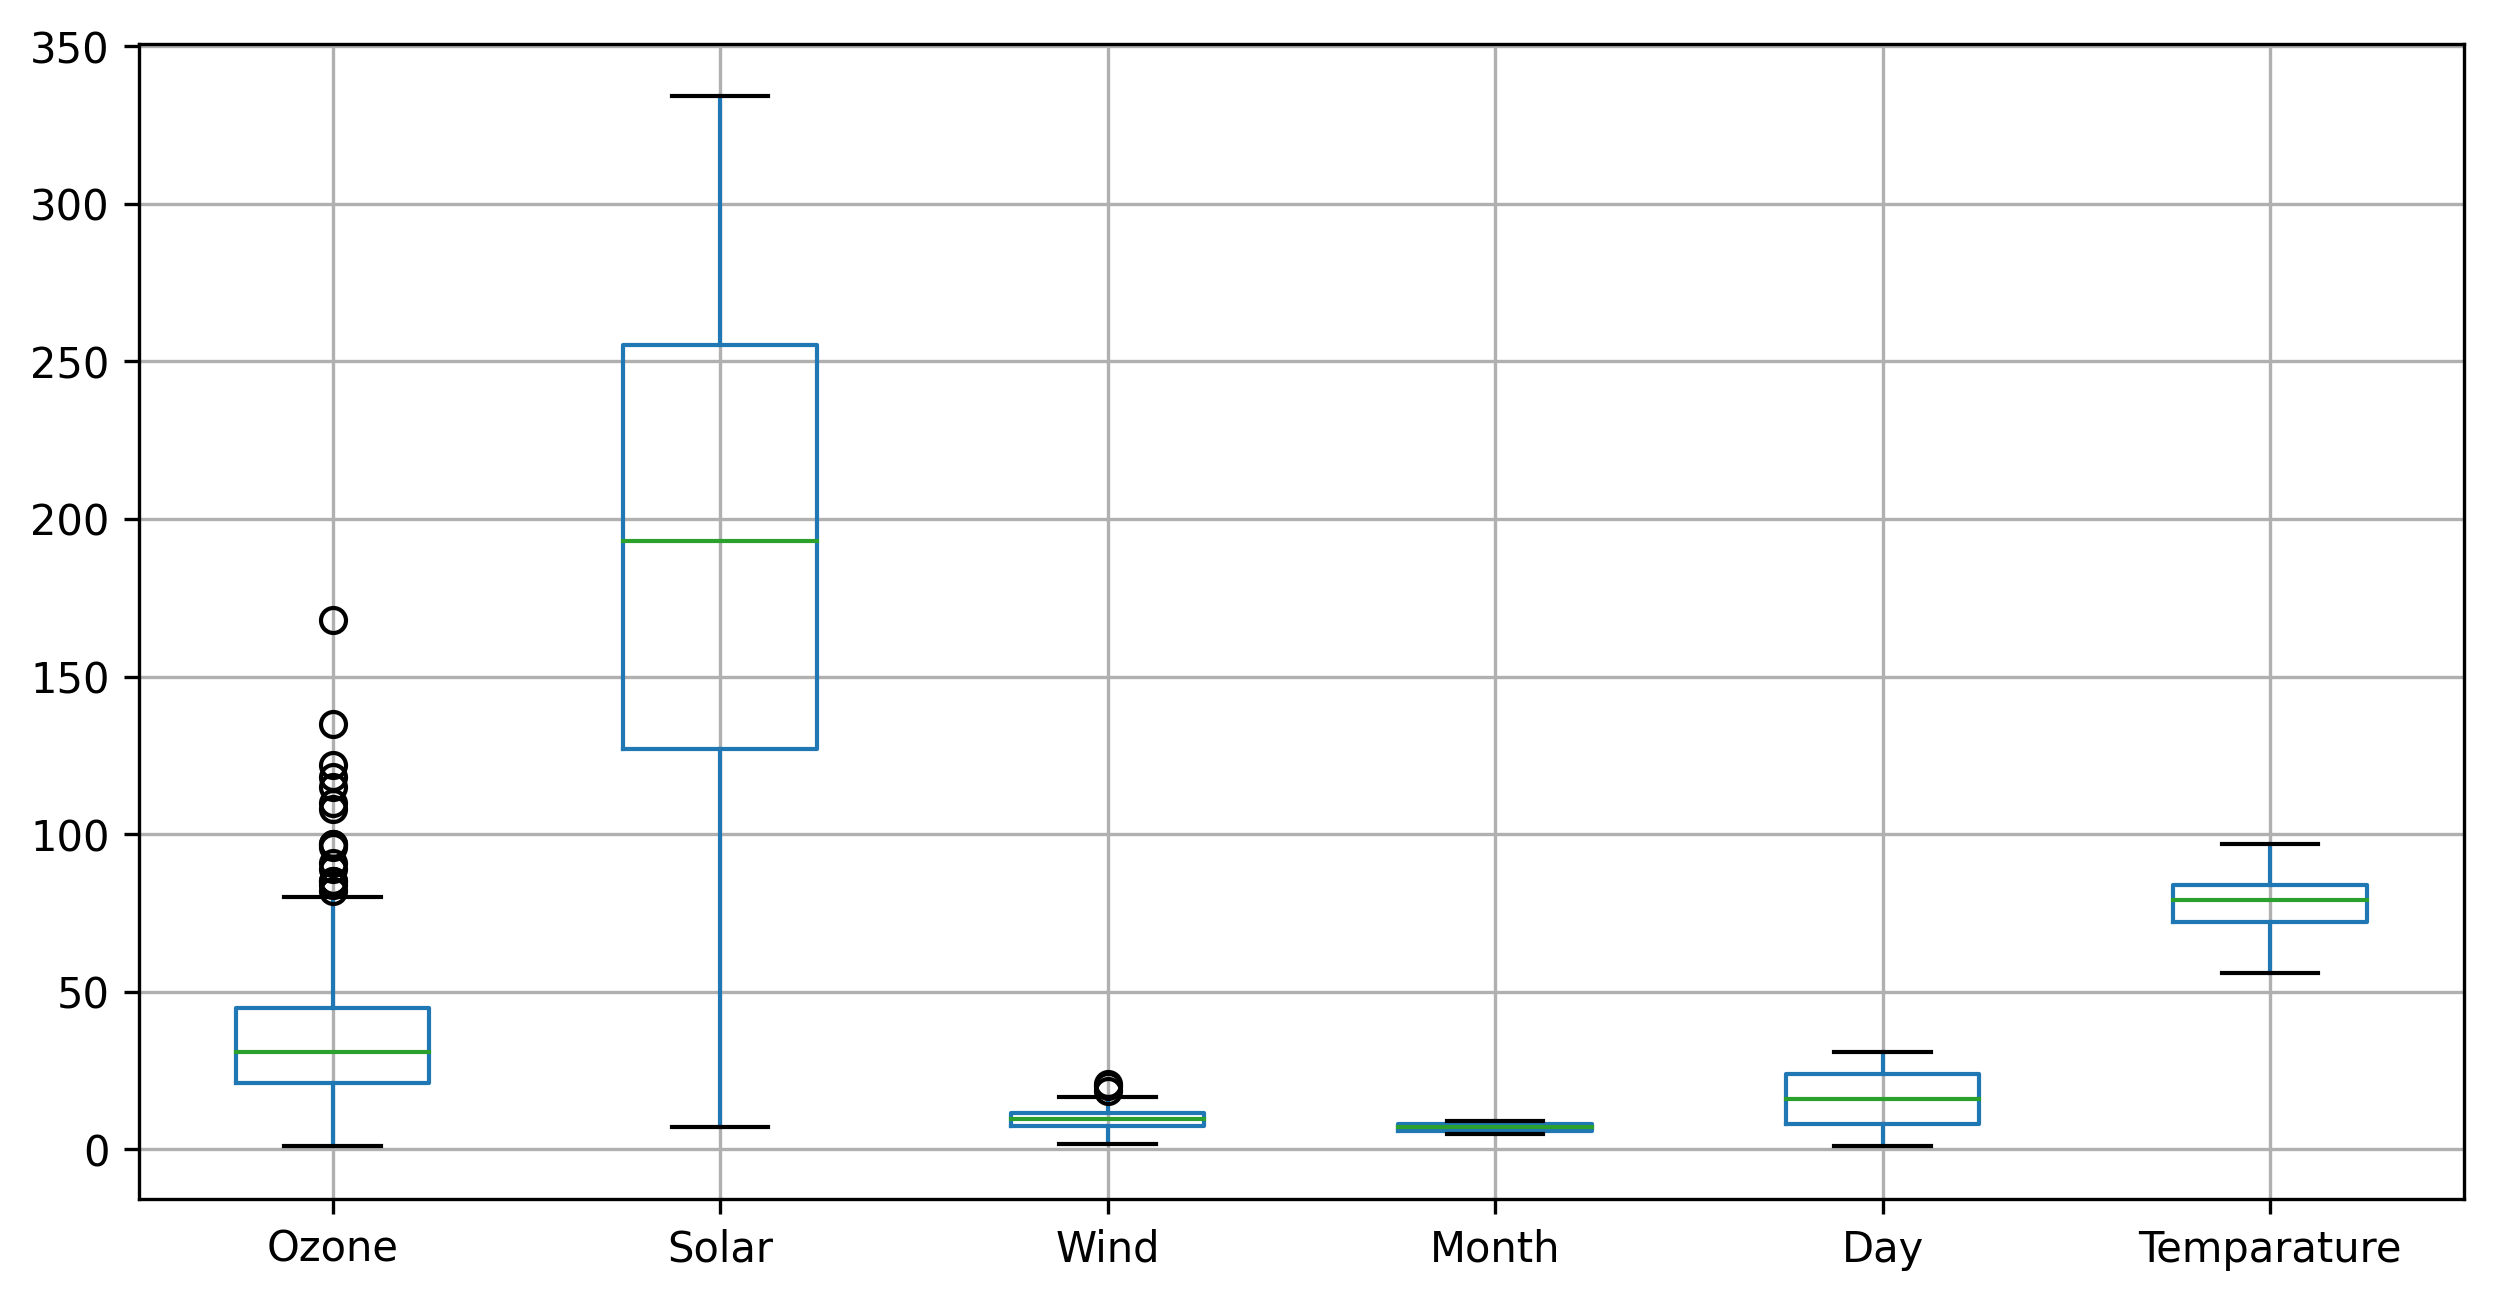

In [63]:
df.boxplot()

<Axes: xlabel='Ozone'>

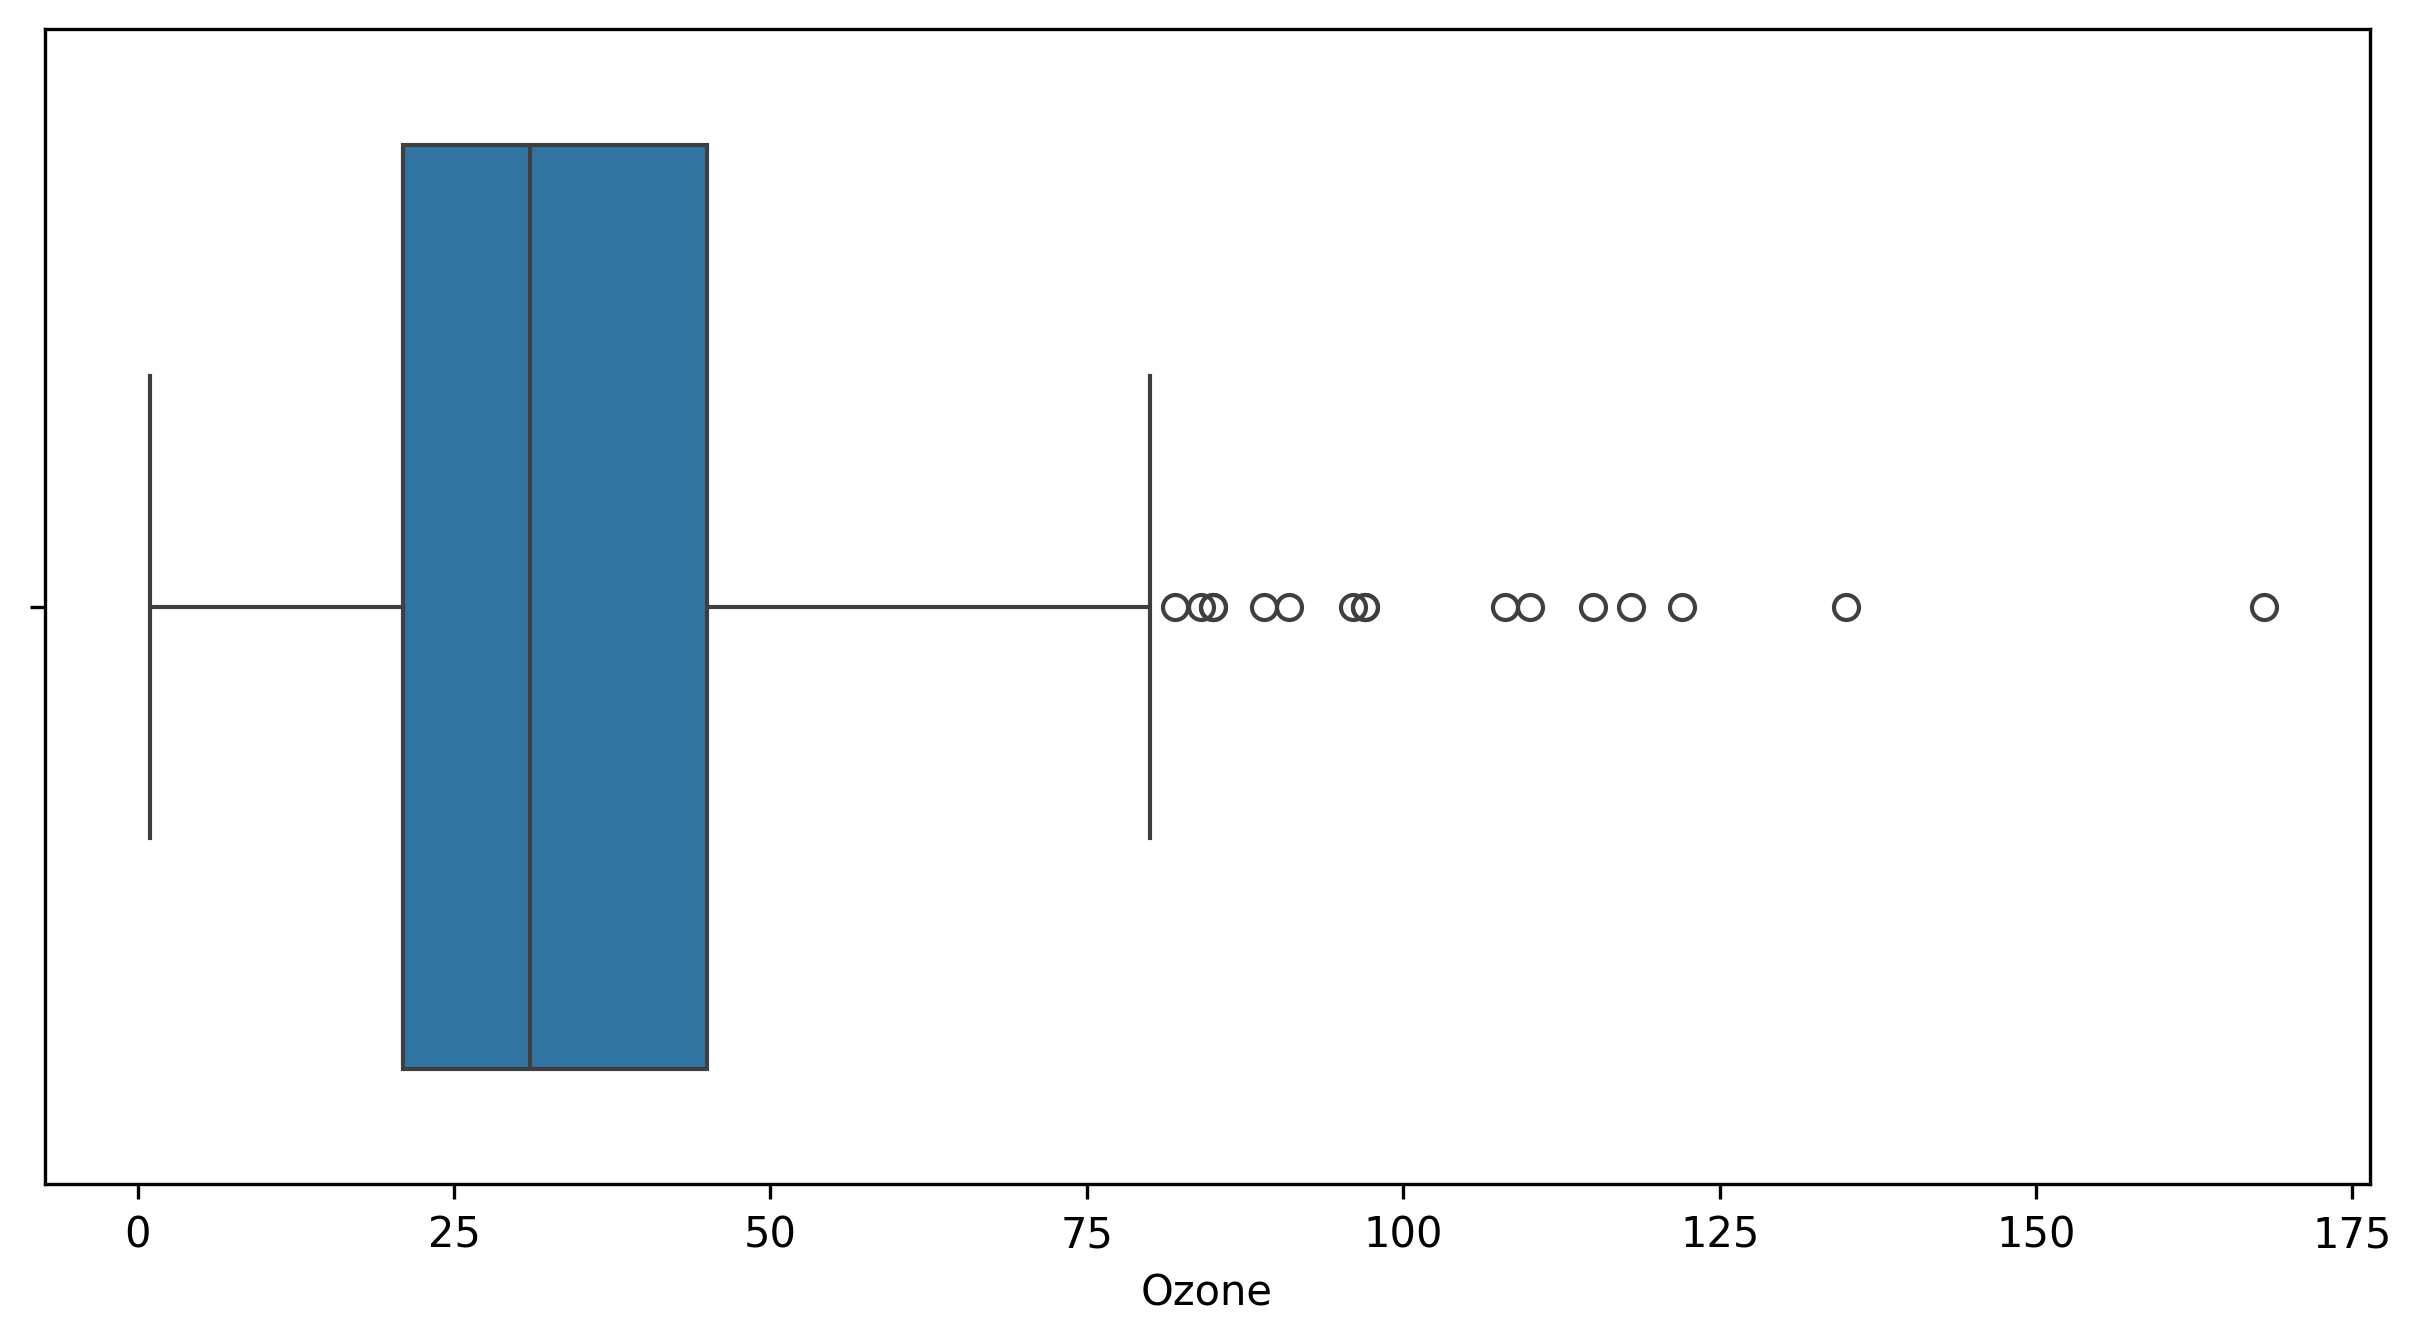

In [64]:
sns.boxplot(x=df["Ozone"])

# Outlier Treatment


*   capping replacing outlier values is called capping
*   In capping all outlier values will be replaced by upper extreame


In [ ]:
def userfunction():
  print("hello")
  print("function Introduction")

In [ ]:
userfunction()

hello
function Introduction


In [65]:
def add(a,b):
  print(a+b)


In [66]:
add(10,20)

30


In [67]:
def arith(num1,num2):
  print("addition",num1+num2)
  print("subtraction",num1-num2)
  print("multiplication",num1*num2)
  print("division",num1/num2)

In [68]:
arith(20,4)

addition 24
subtraction 16
multiplication 80
division 5.0


In [69]:
"Data"+"Science"

'DataScience'

In [70]:
"Data"+" "+"Science"

'Data Science'

In [71]:
def addtext(txt1,txt2):
  print(txt1+" "+txt2)

In [72]:
addtext("string","concatenation")

string concatenation


In [73]:
df["Ozone"].quantile(0.25)

21.0

In [74]:
df["Ozone"].quantile(0.75)

45.0

In [80]:
#Outliesr detection : user defined function to calculate upper extreame and lower extreame
def outlier_detection(data,colname):
  q1=data[colname].quantile(0.25)
  q2=data[colname].quantile(0.75)

  iqr=q2-q1
  upper_extreame=q2+(1.5*iqr)
  lower_extreame=q1-(1.5*iqr)
  return lower_extreame,upper_extreame,q1,q2

In [81]:
outlier_detection(df,"Ozone")

(-15.0, 81.0, 21.0, 45.0)

In [82]:
outlier_detection(df,"Wind")

(1.2500000000000009, 17.65, 7.4, 11.5)

In [83]:
df[df["Ozone"]>81.0]

,Ozone,Solar,Wind,Month,Day,Temparature,Weather
29,115.0,223.0,5.7,5,30,79,C
61,135.0,269.0,4.1,7,1,84,S
68,97.0,267.0,6.3,7,8,92,PS
69,97.0,272.0,5.7,7,9,92,C
70,85.0,175.0,7.4,7,10,89,PS
85,108.0,223.0,8.0,7,25,85,PS
88,82.0,213.0,7.4,7,28,88,S
98,122.0,255.0,4.0,8,7,89,C
99,89.0,229.0,10.3,8,8,90,PS
100,110.0,207.0,8.0,8,9,90,C


In [84]:
df[df["Ozone"]>81.0].shape

(16, 7)

In [85]:
df[df["Ozone"]>81.0].shape[0]

16

In [86]:
len(df[df["Ozone"]>81.0])

16

In [87]:
#Now all these 16 outliers values of ozone column should be replaced by upper extreame
df.loc[df["Ozone"]>81.0,"Ozone"]

,Ozone
29,115.0
61,135.0
68,97.0
69,97.0
70,85.0
85,108.0
88,82.0
98,122.0
99,89.0
100,110.0


In [88]:
# capping outliers of ozone column
df.loc[df["Ozone"]>81.0,"Ozone"]=81

In [89]:
df[df["Ozone"]>81.0]
#no values are displayed .. as all out liers are replaced by 81.0

,Ozone,Solar,Wind,Month,Day,Temparature,Weather


In [90]:
df[df["Ozone"]==81.0]

,Ozone,Solar,Wind,Month,Day,Temparature,Weather
29,81.0,223.0,5.7,5,30,79,C
61,81.0,269.0,4.1,7,1,84,S
68,81.0,267.0,6.3,7,8,92,PS
69,81.0,272.0,5.7,7,9,92,C
70,81.0,175.0,7.4,7,10,89,PS
85,81.0,223.0,8.0,7,25,85,PS
88,81.0,213.0,7.4,7,28,88,S
98,81.0,255.0,4.0,8,7,89,C
99,81.0,229.0,10.3,8,8,90,PS
100,81.0,207.0,8.0,8,9,90,C


In [91]:
# do it for wind column also
outlier_detection(df,"Wind")

(1.2500000000000009, 17.65, 7.4, 11.5)

<Axes: xlabel='Wind'>

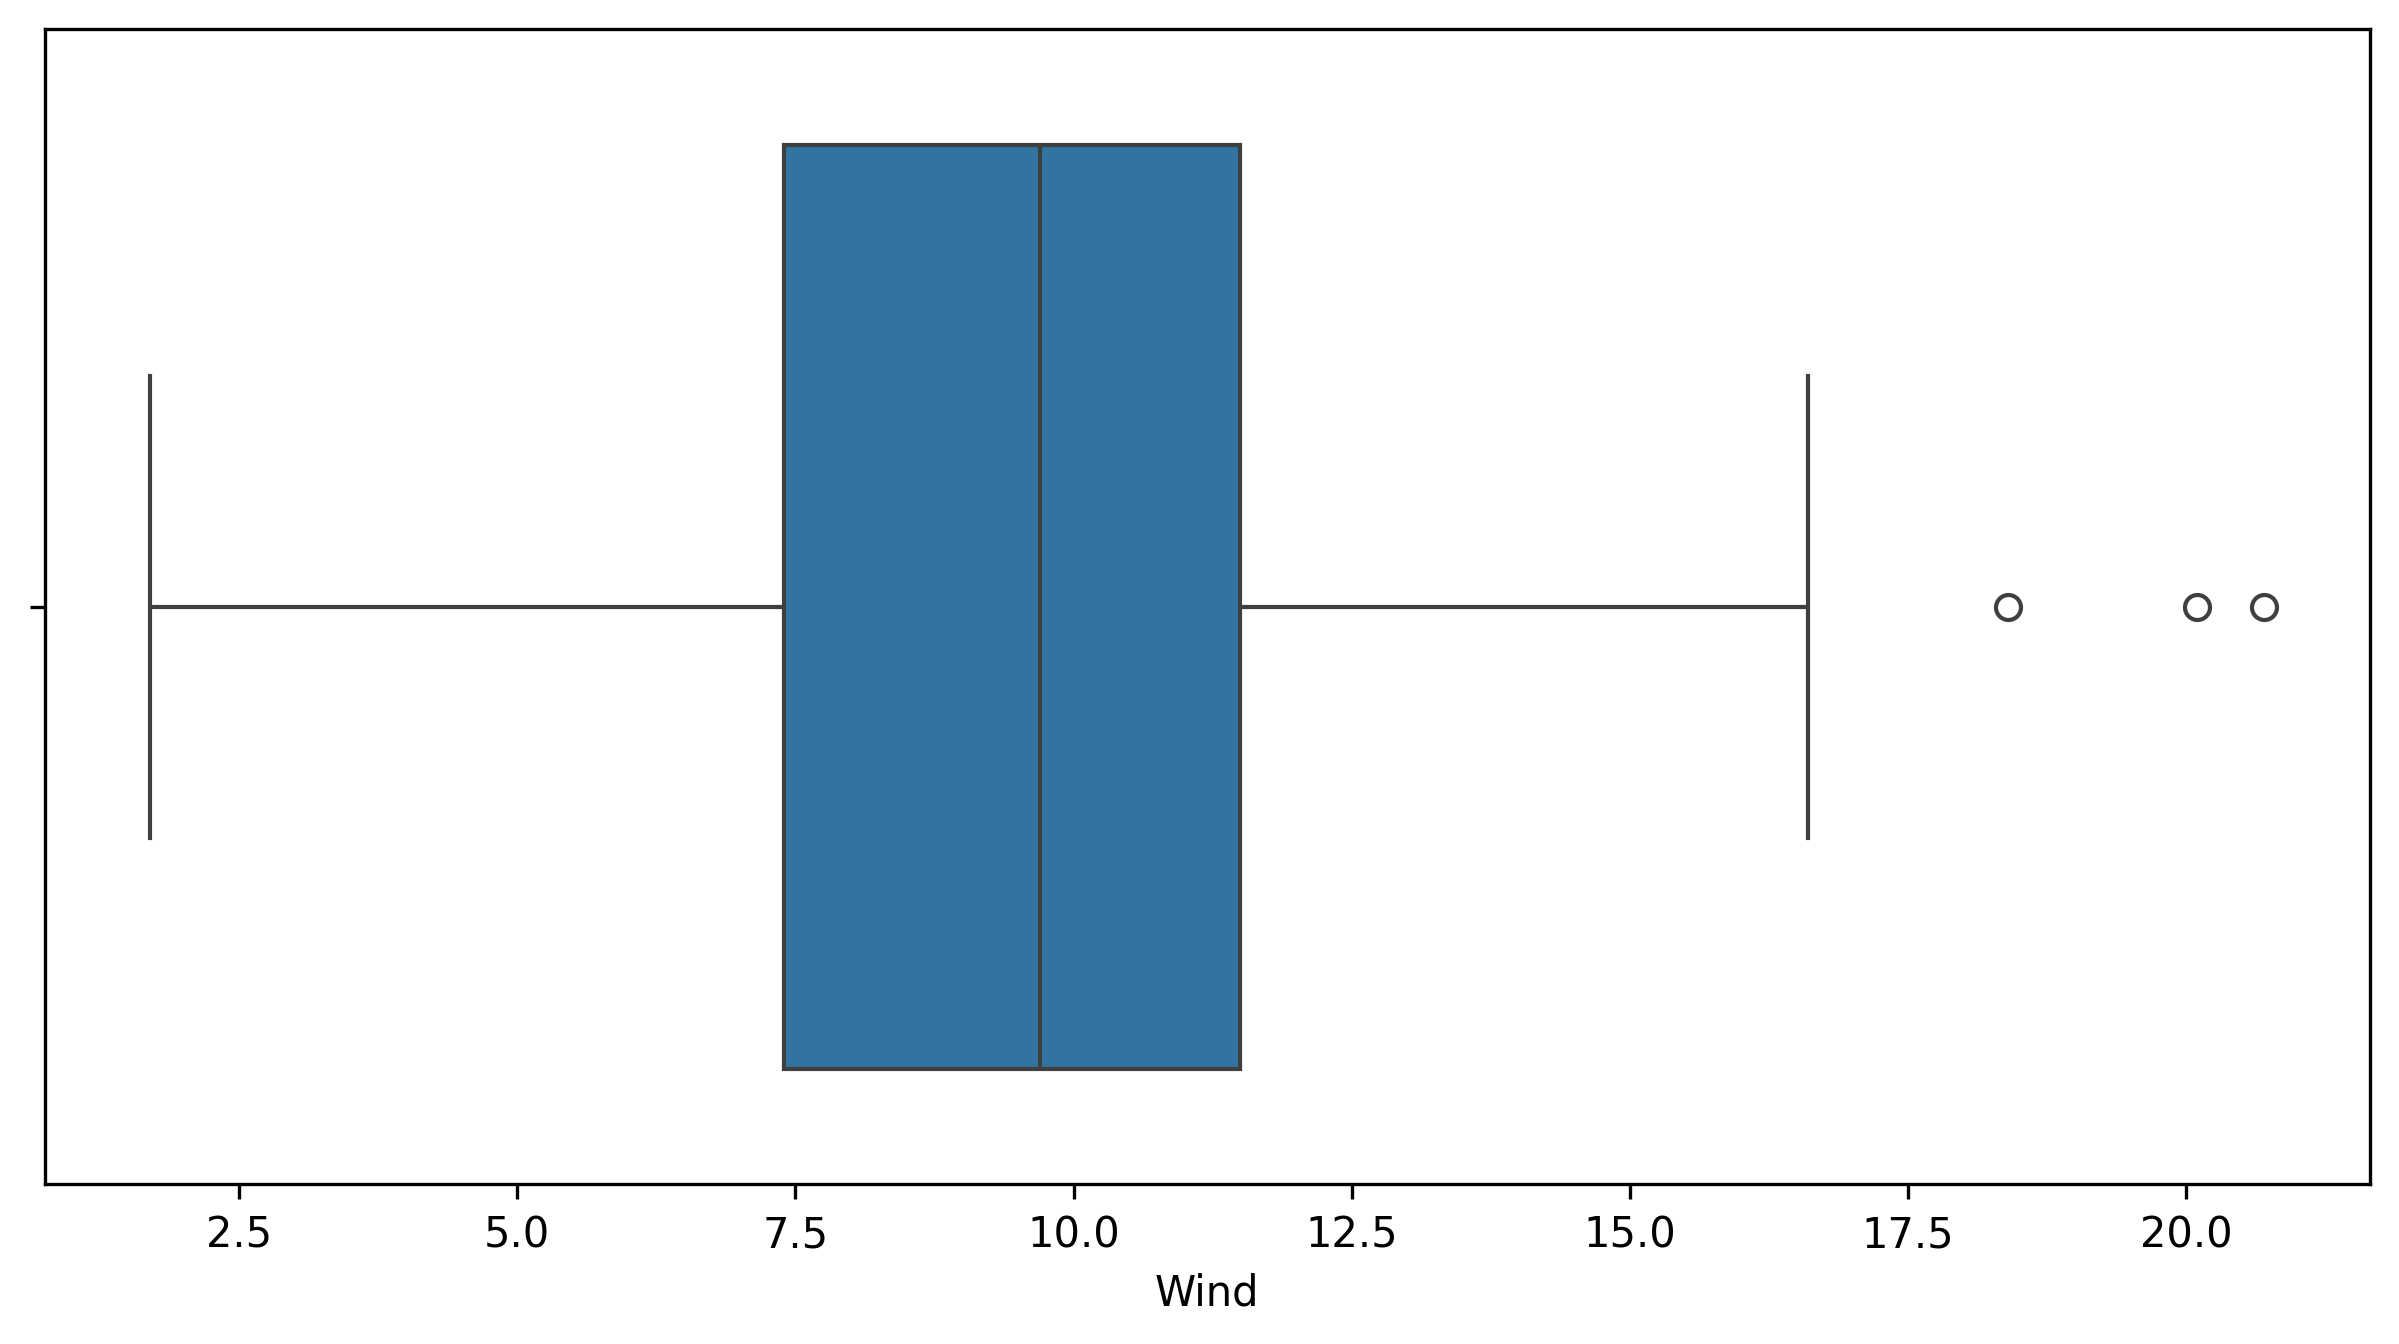

In [93]:
sns.boxplot(x=df["Wind"])

In [95]:
#upper extreame value for Wind is 17.65. so replace all values of wind column which are greater than 17.65
df[df["Wind"]>17.65]

,Ozone,Solar,Wind,Month,Day,Temparature,Weather
8,8.0,19.0,20.1,5,9,61,PS
17,6.0,78.0,18.4,5,18,57,C
47,37.0,284.0,20.7,6,17,72,C


In [96]:
df.loc[df["Wind"]>17.65,"Wind"]=17.65

In [98]:
df[df["Wind"]==17.65]

,Ozone,Solar,Wind,Month,Day,Temparature,Weather
8,8.0,19.0,17.65,5,9,61,PS
17,6.0,78.0,17.65,5,18,57,C
47,37.0,284.0,17.65,6,17,72,C


<Axes: >

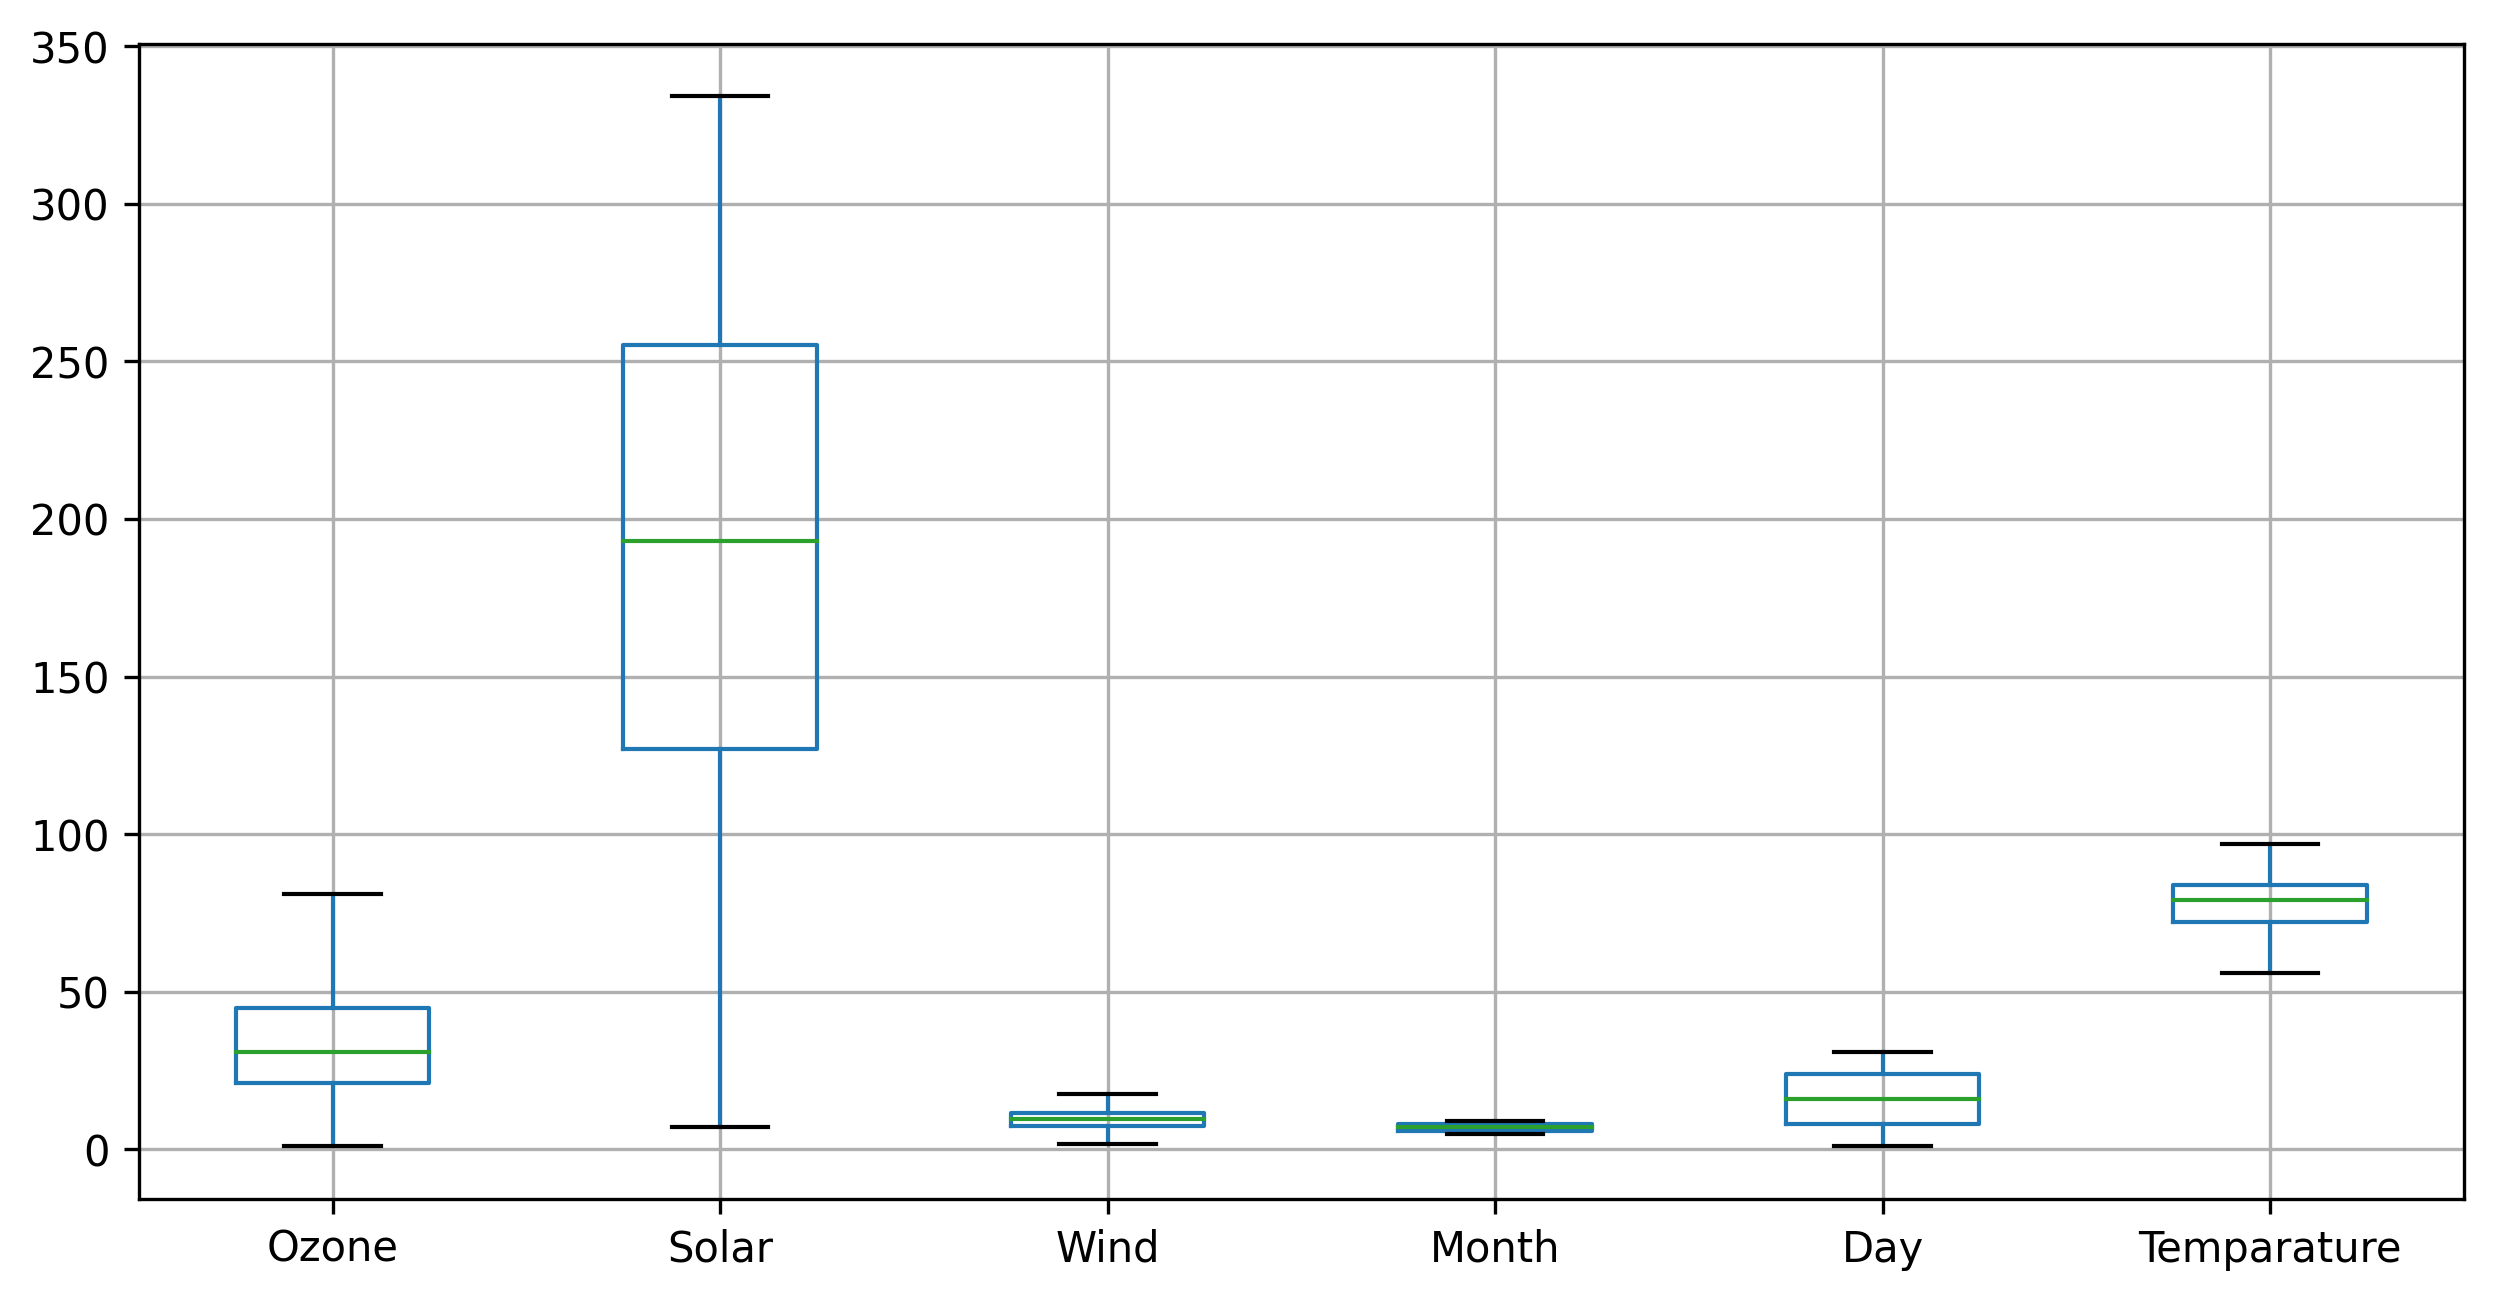

In [97]:
df.boxplot()

In [99]:
df.shape

(157, 7)

# **Scatter plot and Correlation**

In [100]:
df.head()

,Ozone,Solar,Wind,Month,Day,Temparature,Weather
0,41.0,190.000000,7.4,5,1,67,S
1,36.0,118.000000,8.0,5,2,72,C
2,12.0,149.000000,12.6,5,3,74,PS
3,18.0,313.000000,11.5,5,4,62,S
4,31.0,185.366667,14.3,5,5,56,S


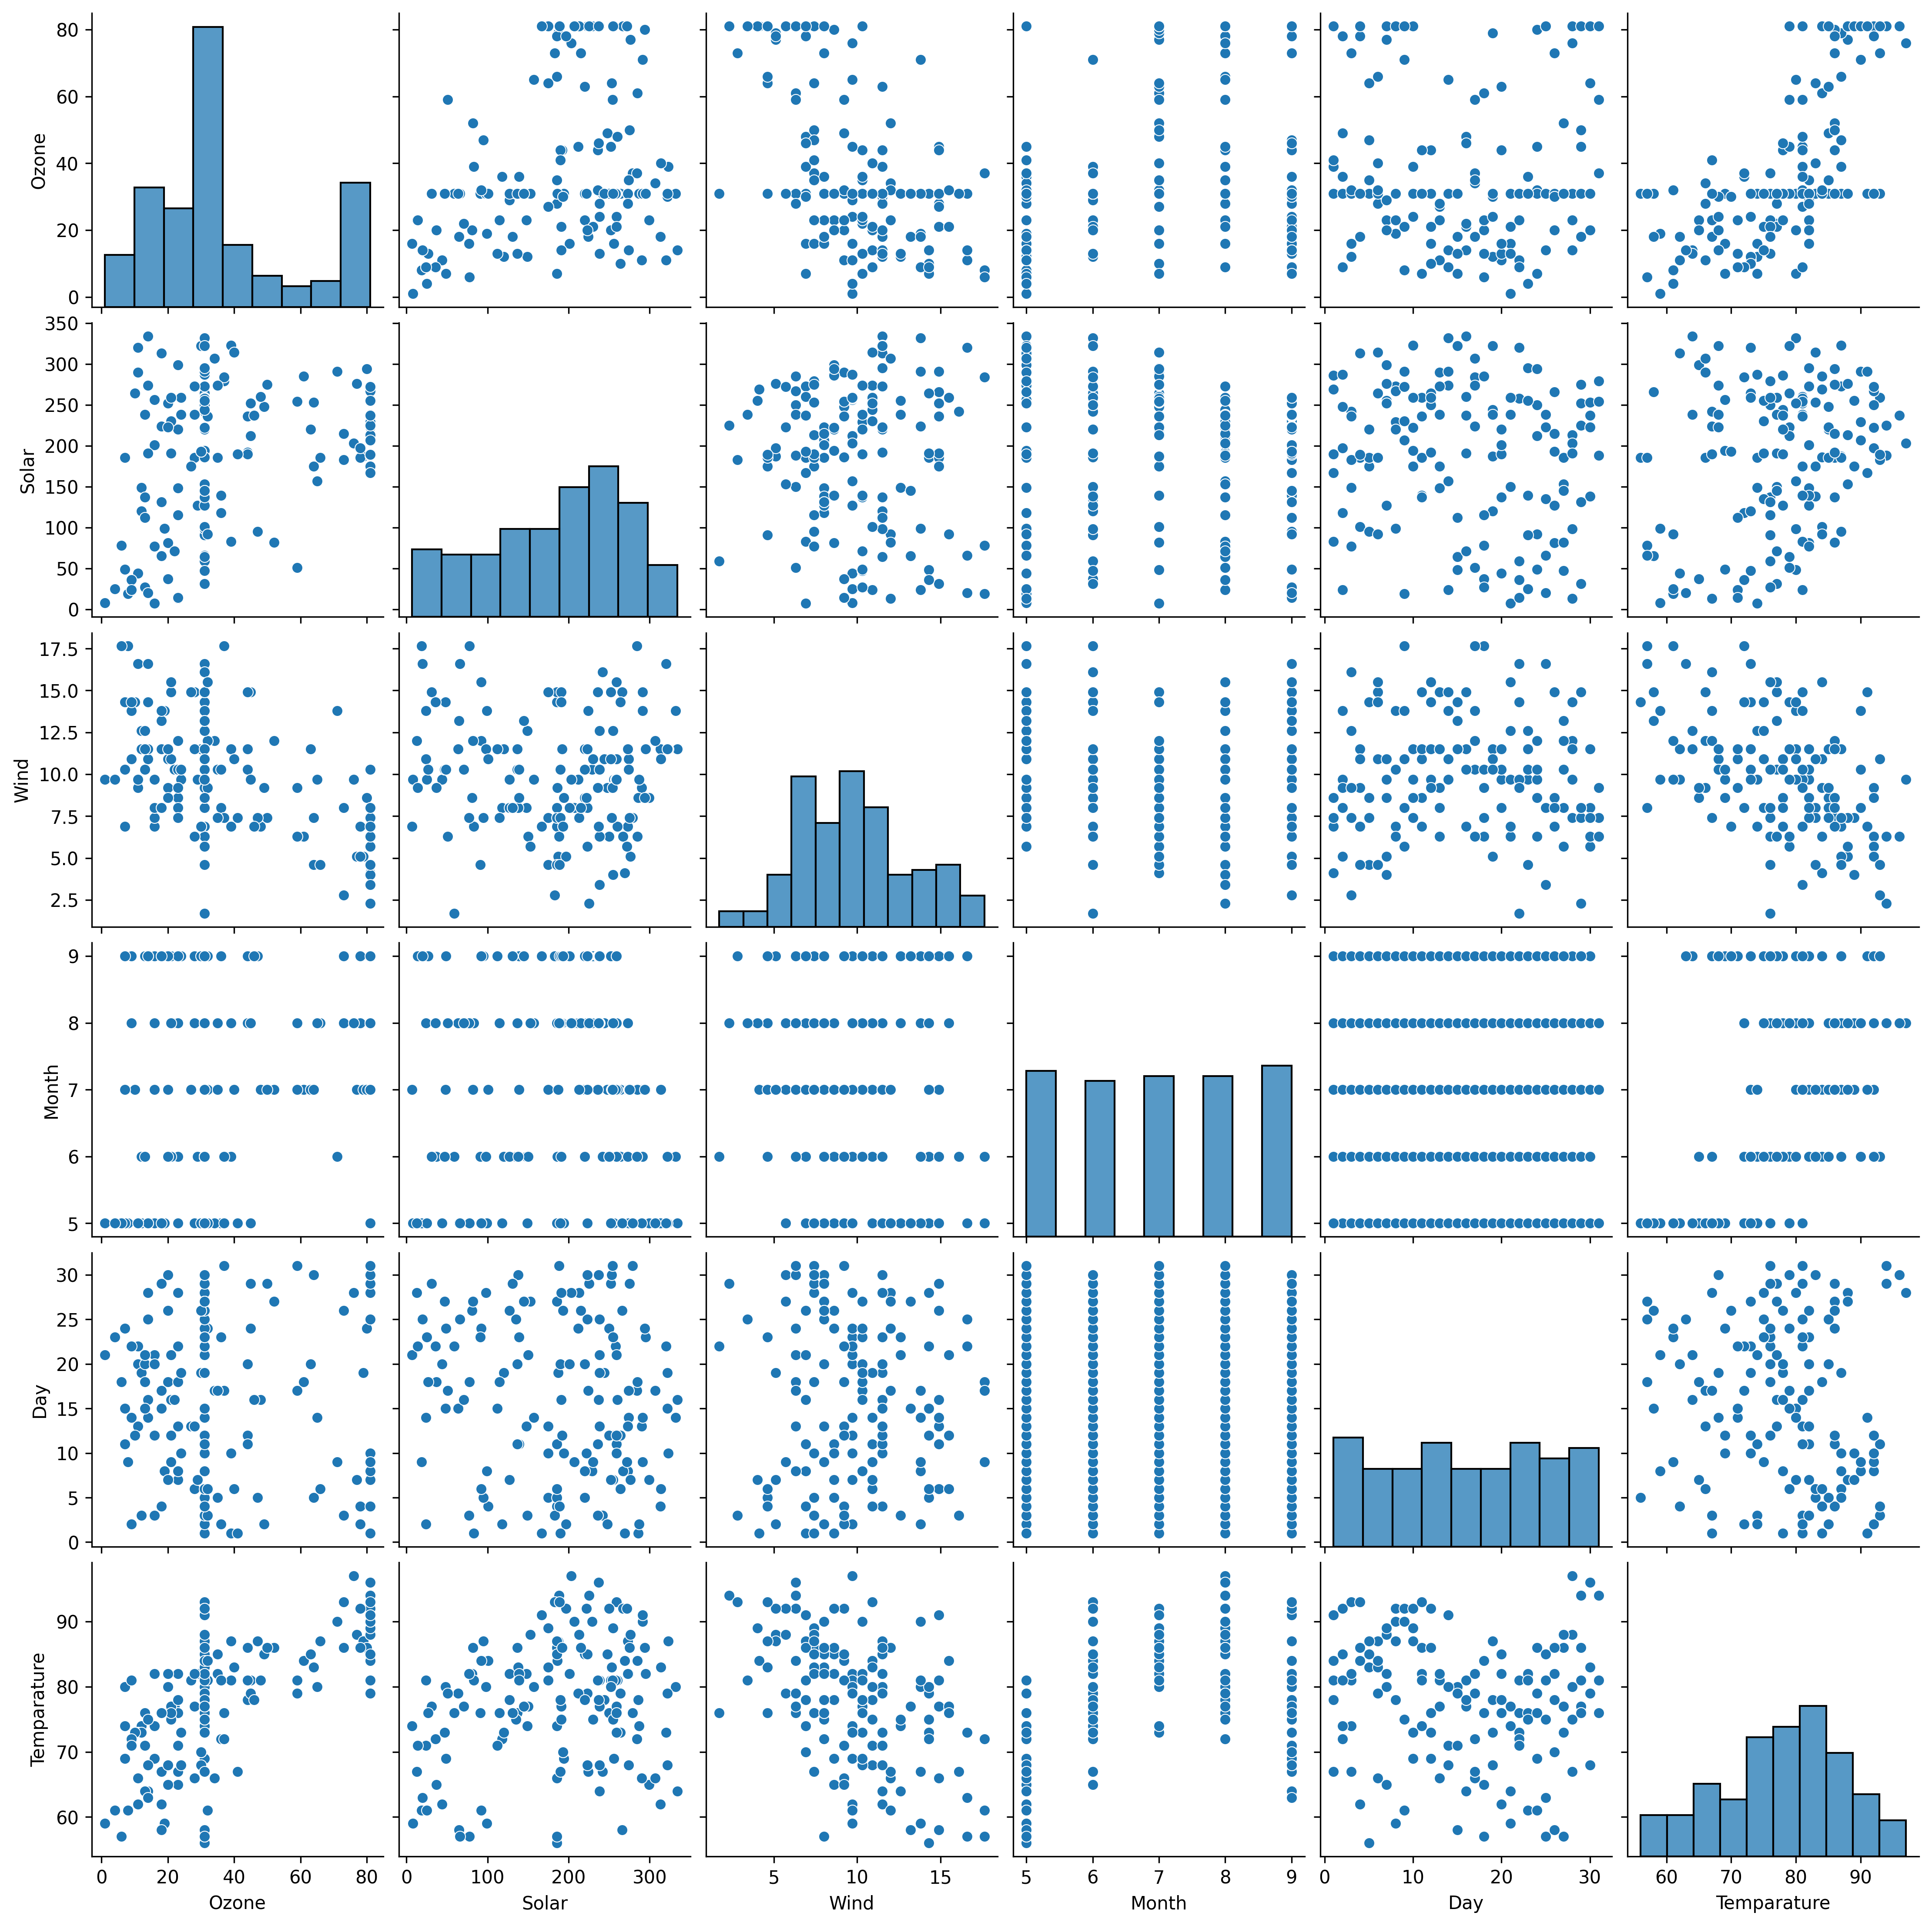

In [101]:
sns.pairplot(df)
# relationship b/w all numerical columns
# check graph of month(x axis) vs temparature(y axis)
# we got 5 vertical lines in it bcz datatype of month is discreate numerical value.
# it shows no relationship b/w month and temparature

In [102]:
df["Weather"].value_counts()

,count
Weather,
S,61
C,49
PS,47


In [105]:
# correlation co effitient
df.corr(numeric_only=True)
# ozone vs ozone corr is 1.0 so ignore diagonal values
# ozone vs temparature corr is 0.66 i,e. positive moderate correlation
# for large no.of columns go for heatmap visualization

,Ozone,Solar,Wind,Month,Day,Temparature
Ozone,1.000000,0.317926,-0.522513,0.183089,-0.042835,0.662773
Solar,0.317926,1.000000,-0.053534,-0.080237,-0.151007,0.260677
Wind,-0.522513,-0.053534,1.000000,-0.162988,0.033374,-0.439939
Month,0.183089,-0.080237,-0.162988,1.000000,0.041438,0.408060
Day,-0.042835,-0.151007,0.033374,0.041438,1.000000,-0.122787
Temparature,0.662773,0.260677,-0.439939,0.408060,-0.122787,1.000000


<Axes: >

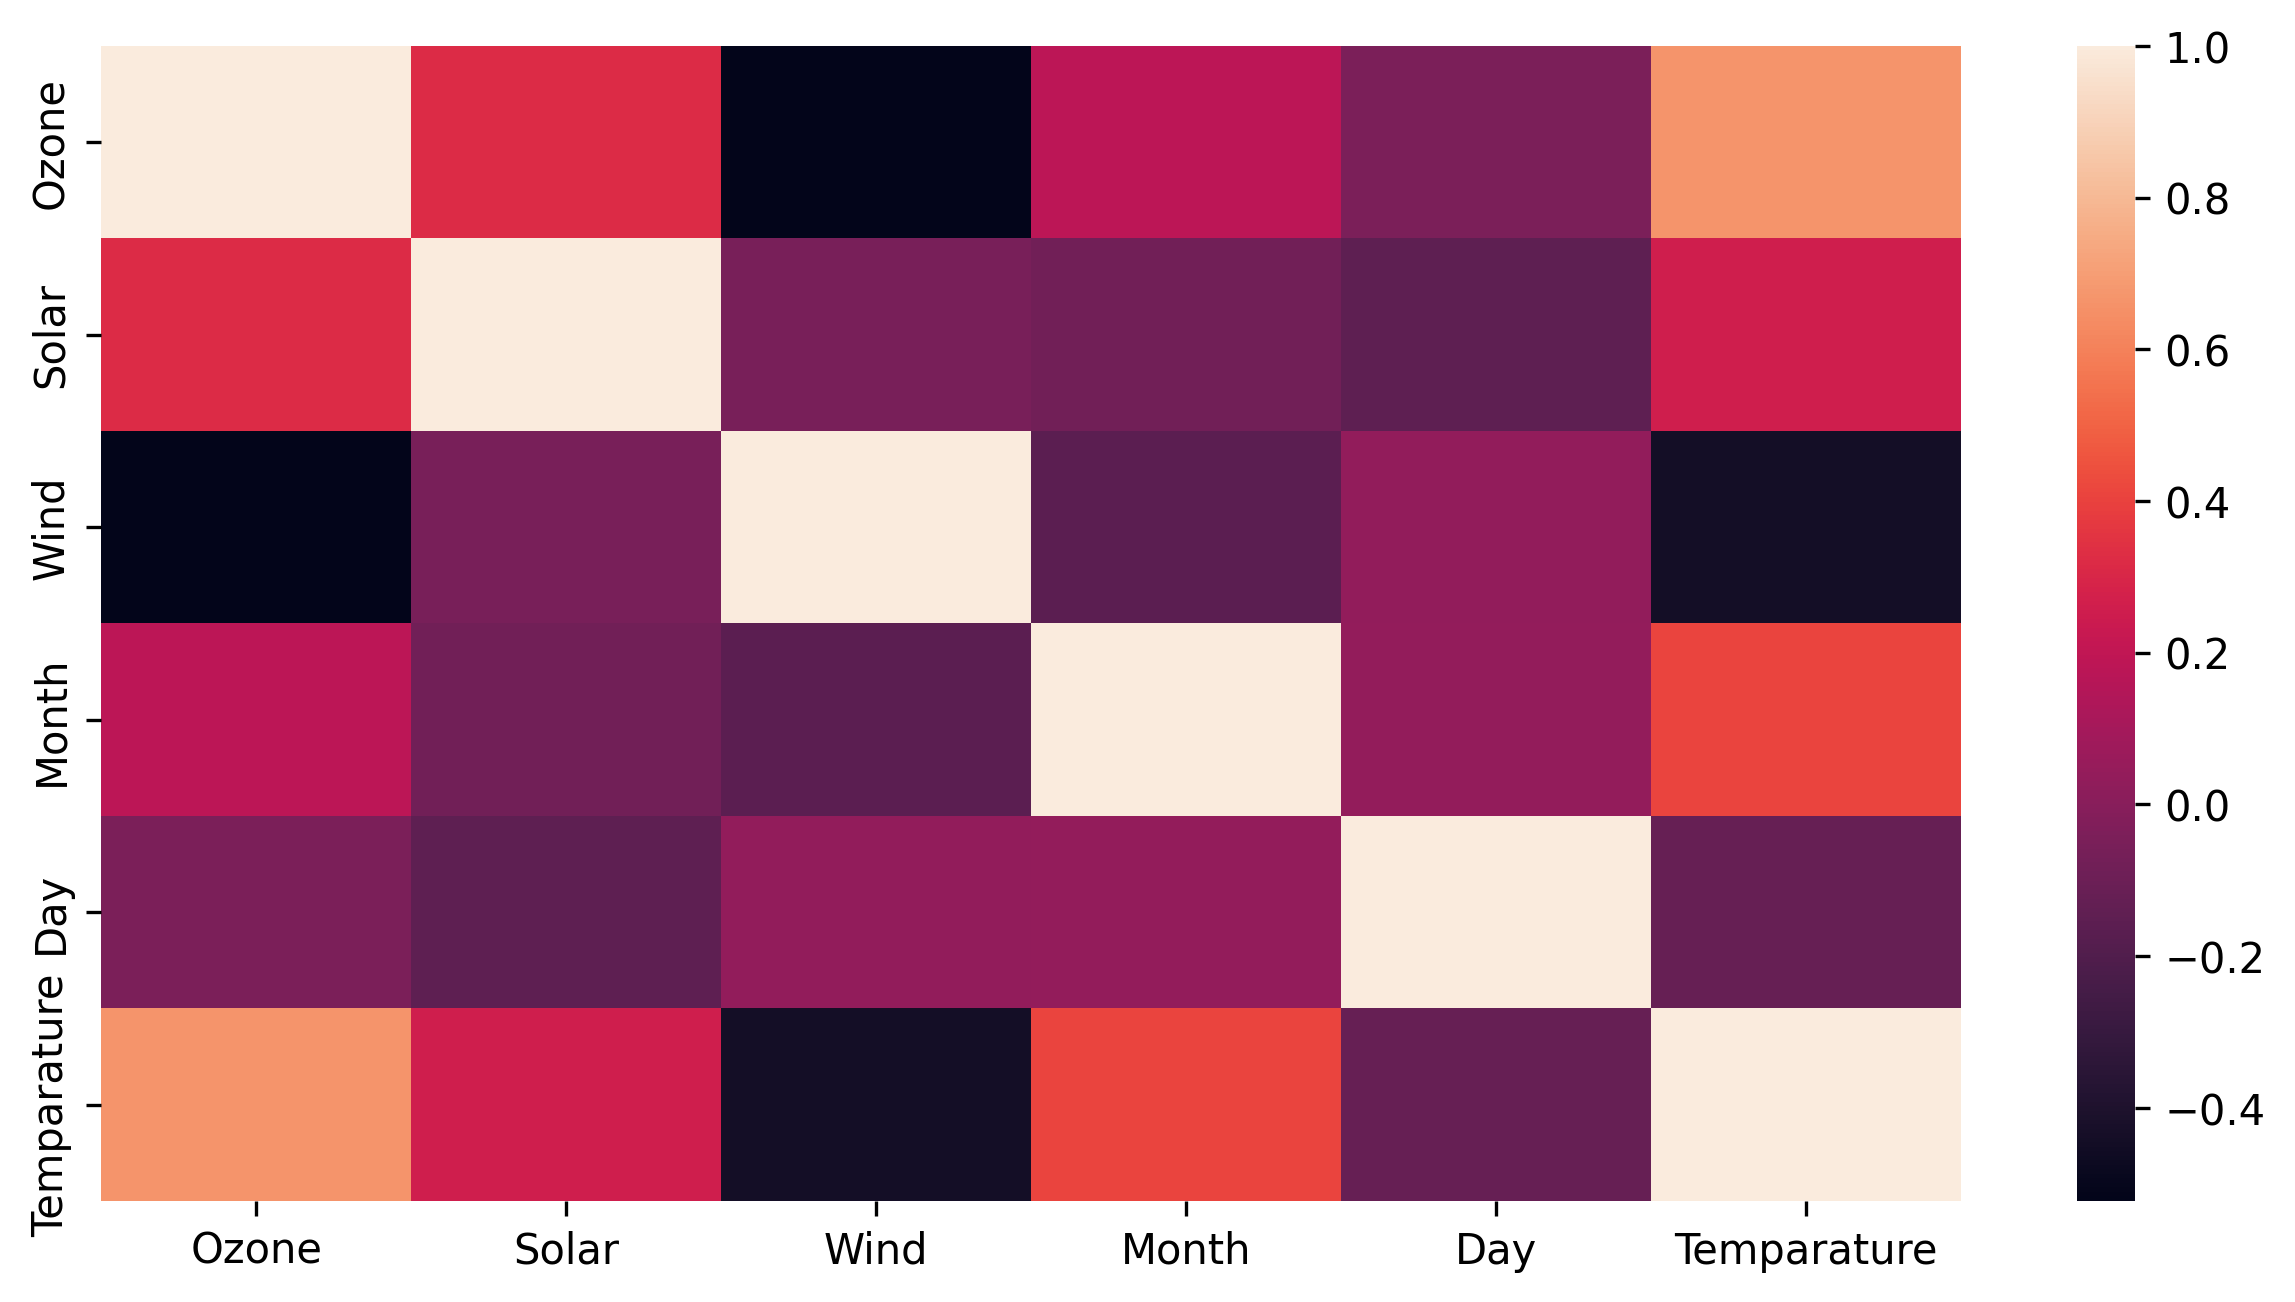

In [106]:
sns.heatmap(df.corr(numeric_only=True))
#see sidebar which shows -1 to 1 values from bottom to top
#on the side vertical bar light color indicates +ve strong relationship
#dark black color indicates strong -ve relationship
# for clear un derstanding pass parameters to heatmap

<Axes: >

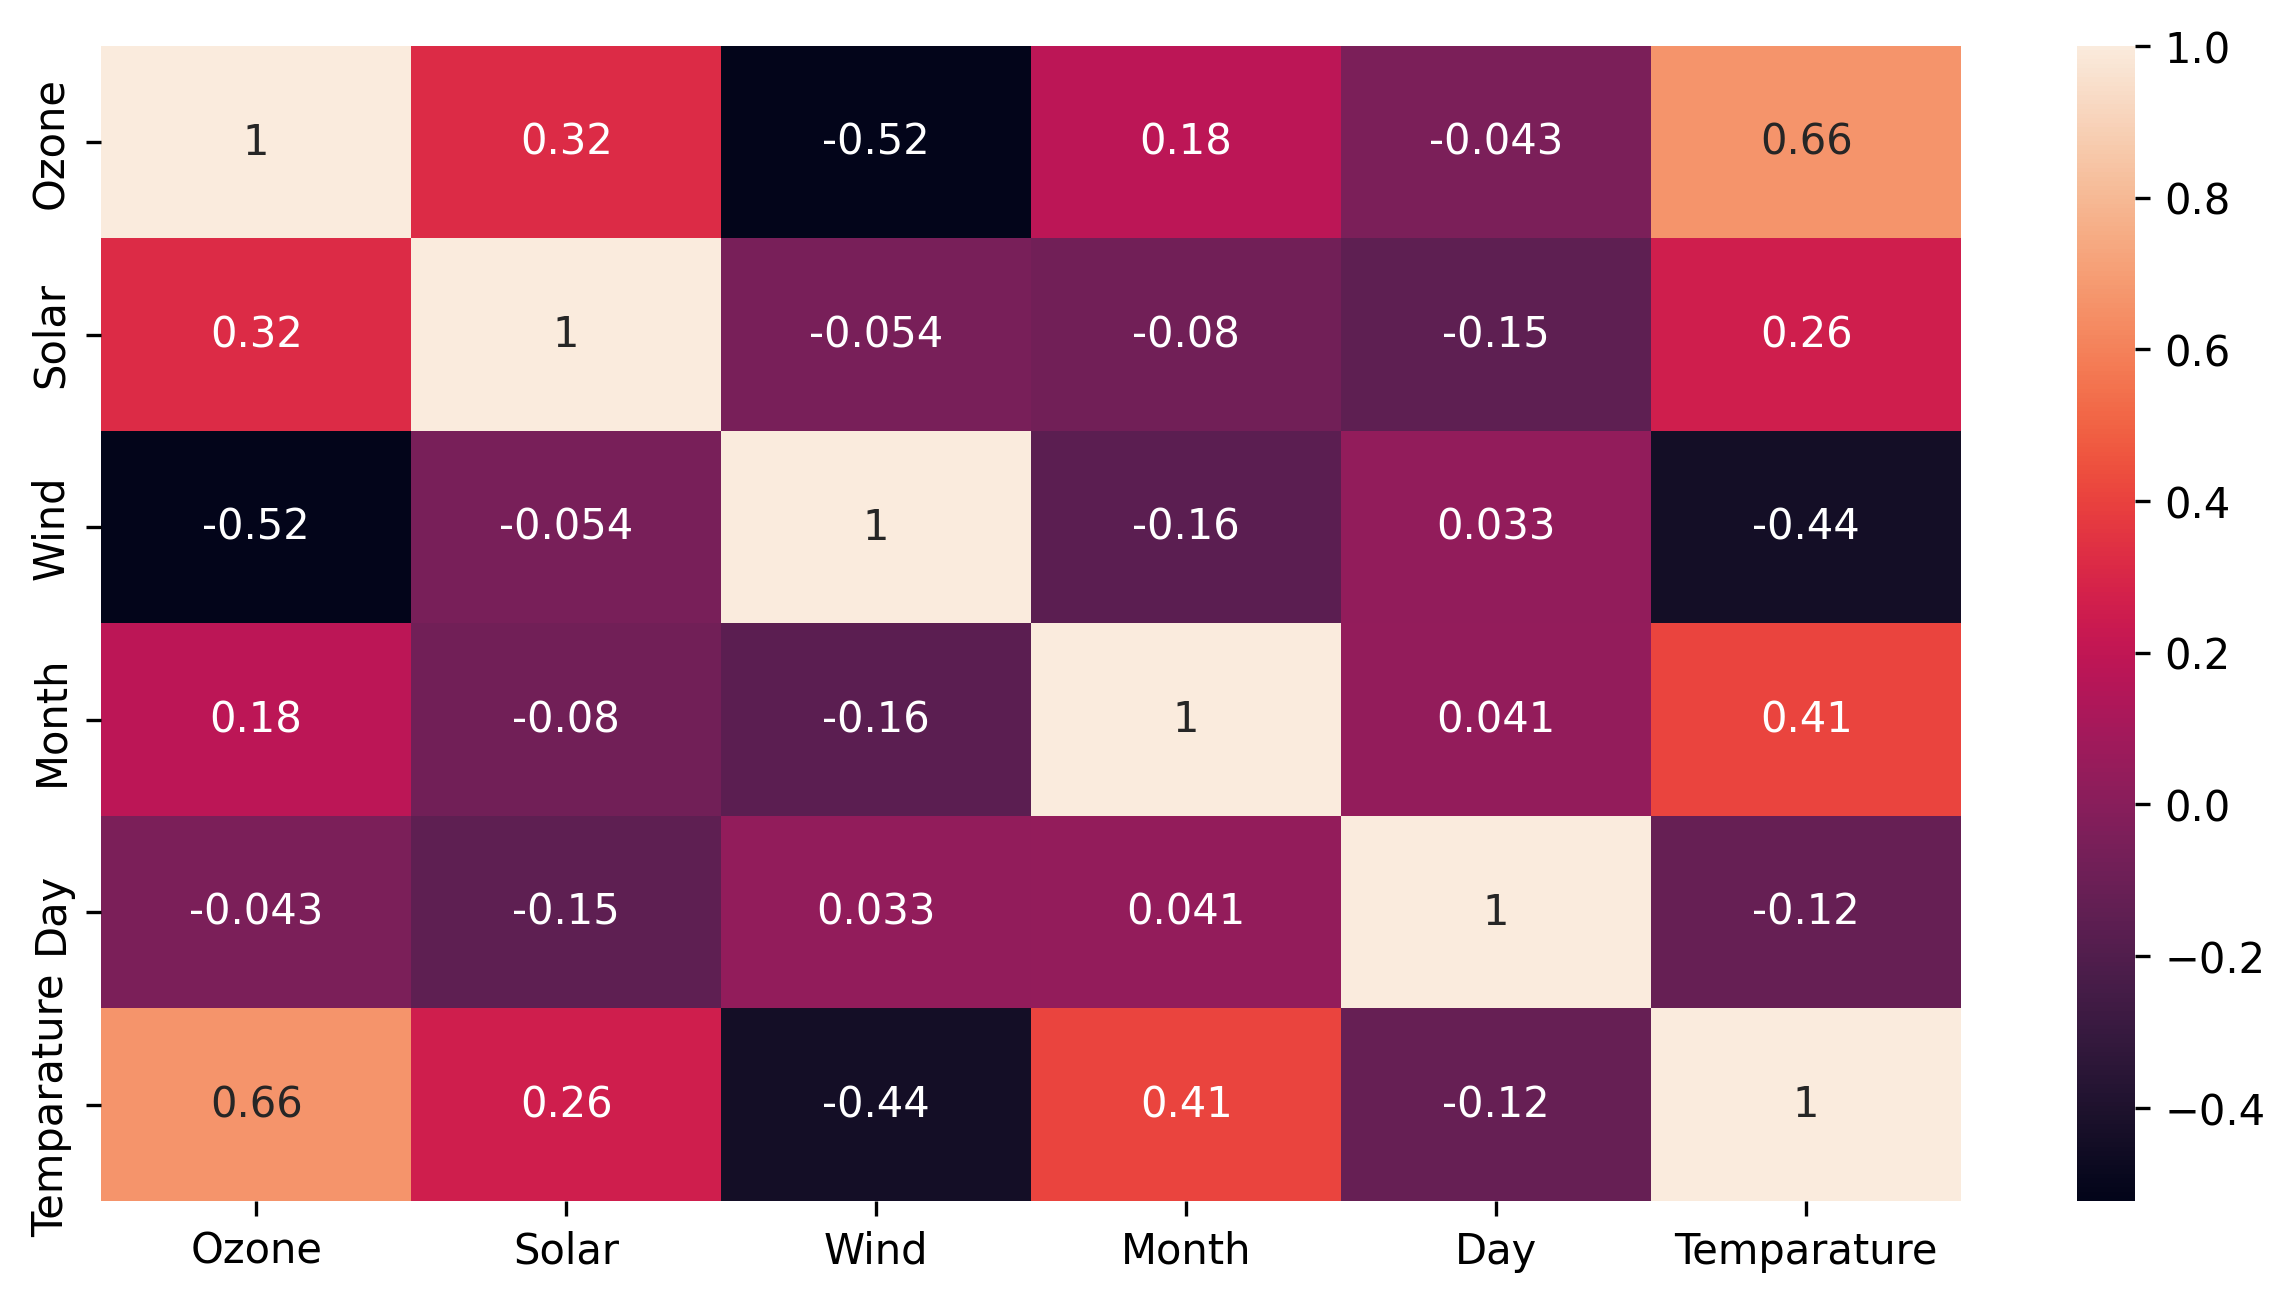

In [107]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
#colors are representing correlation value also

<Axes: >

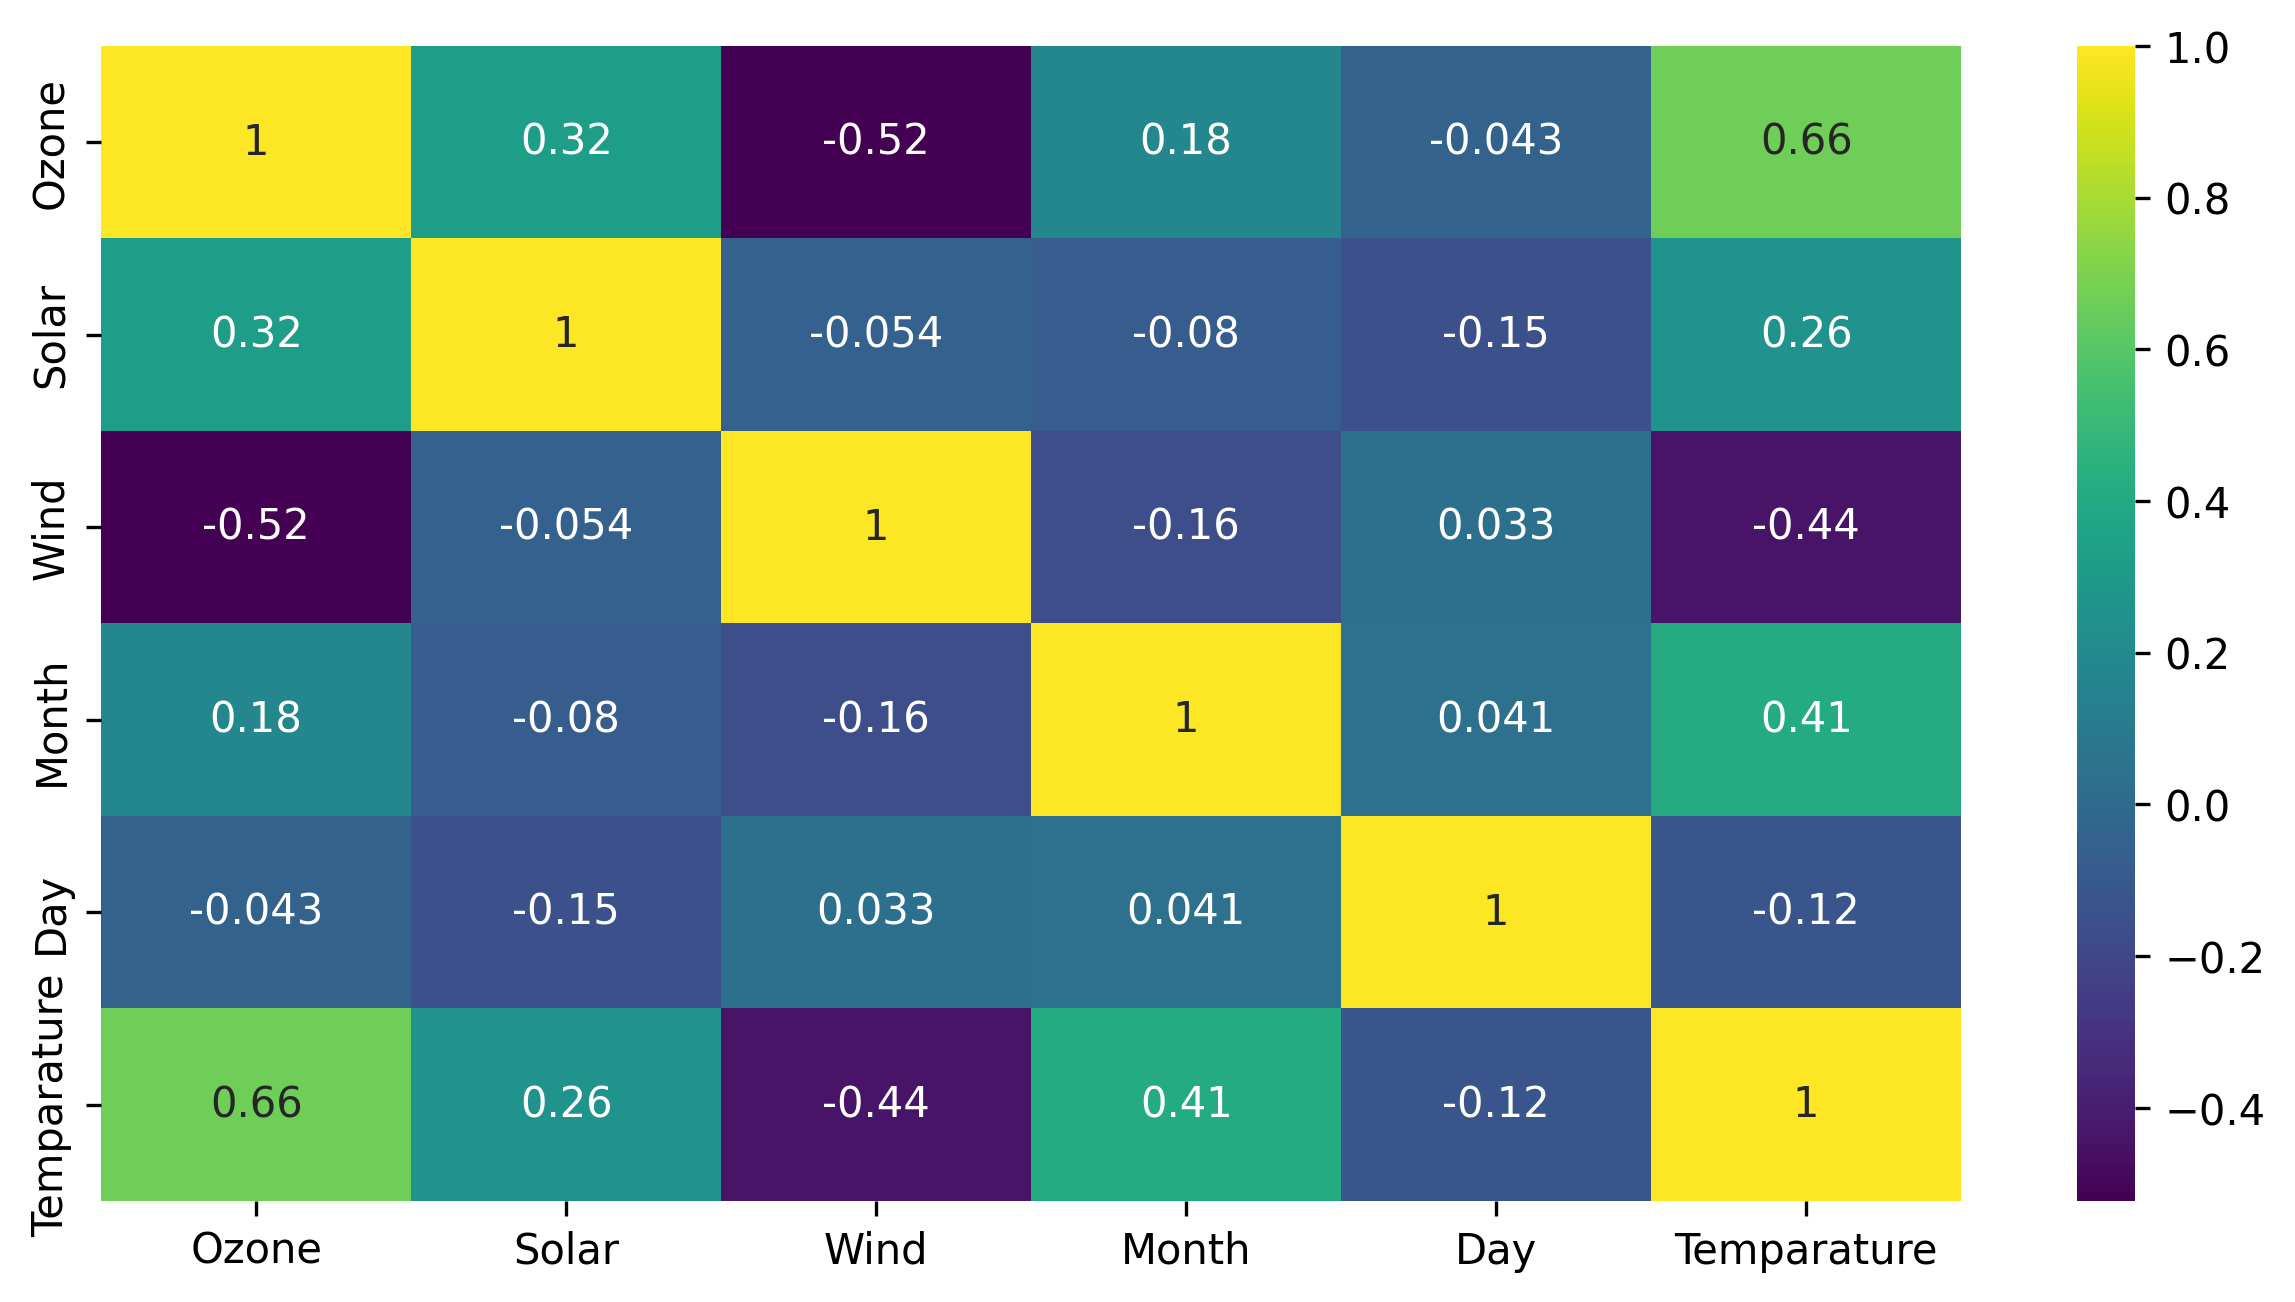

In [108]:
#we can change color combination also
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="viridis")

<Axes: >

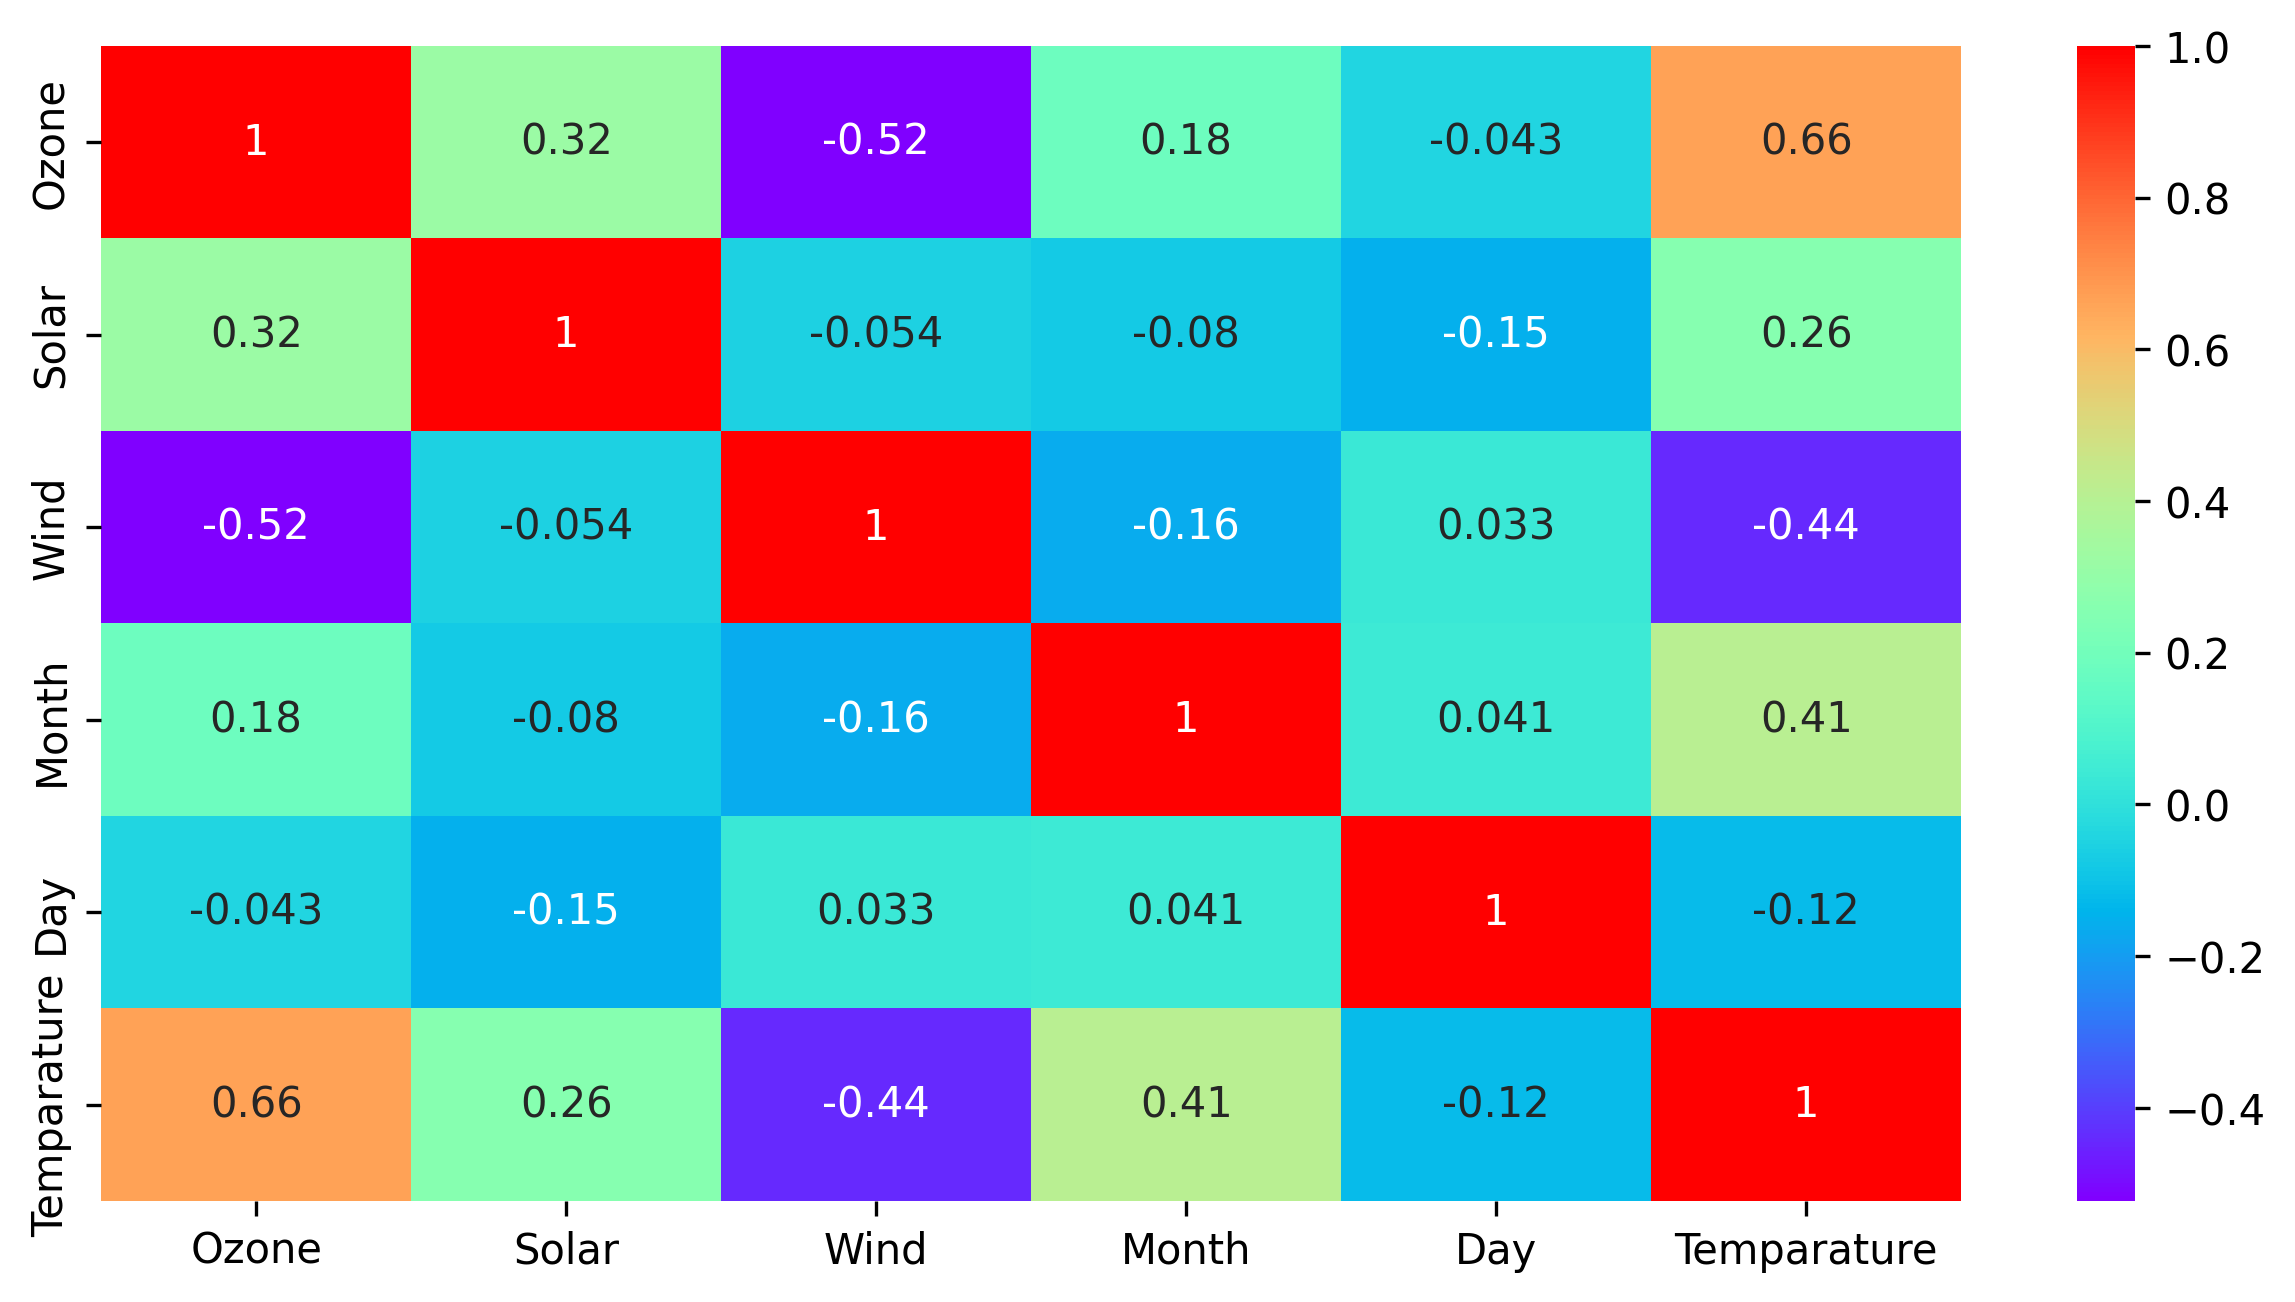

In [109]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="rainbow")

<Axes: >

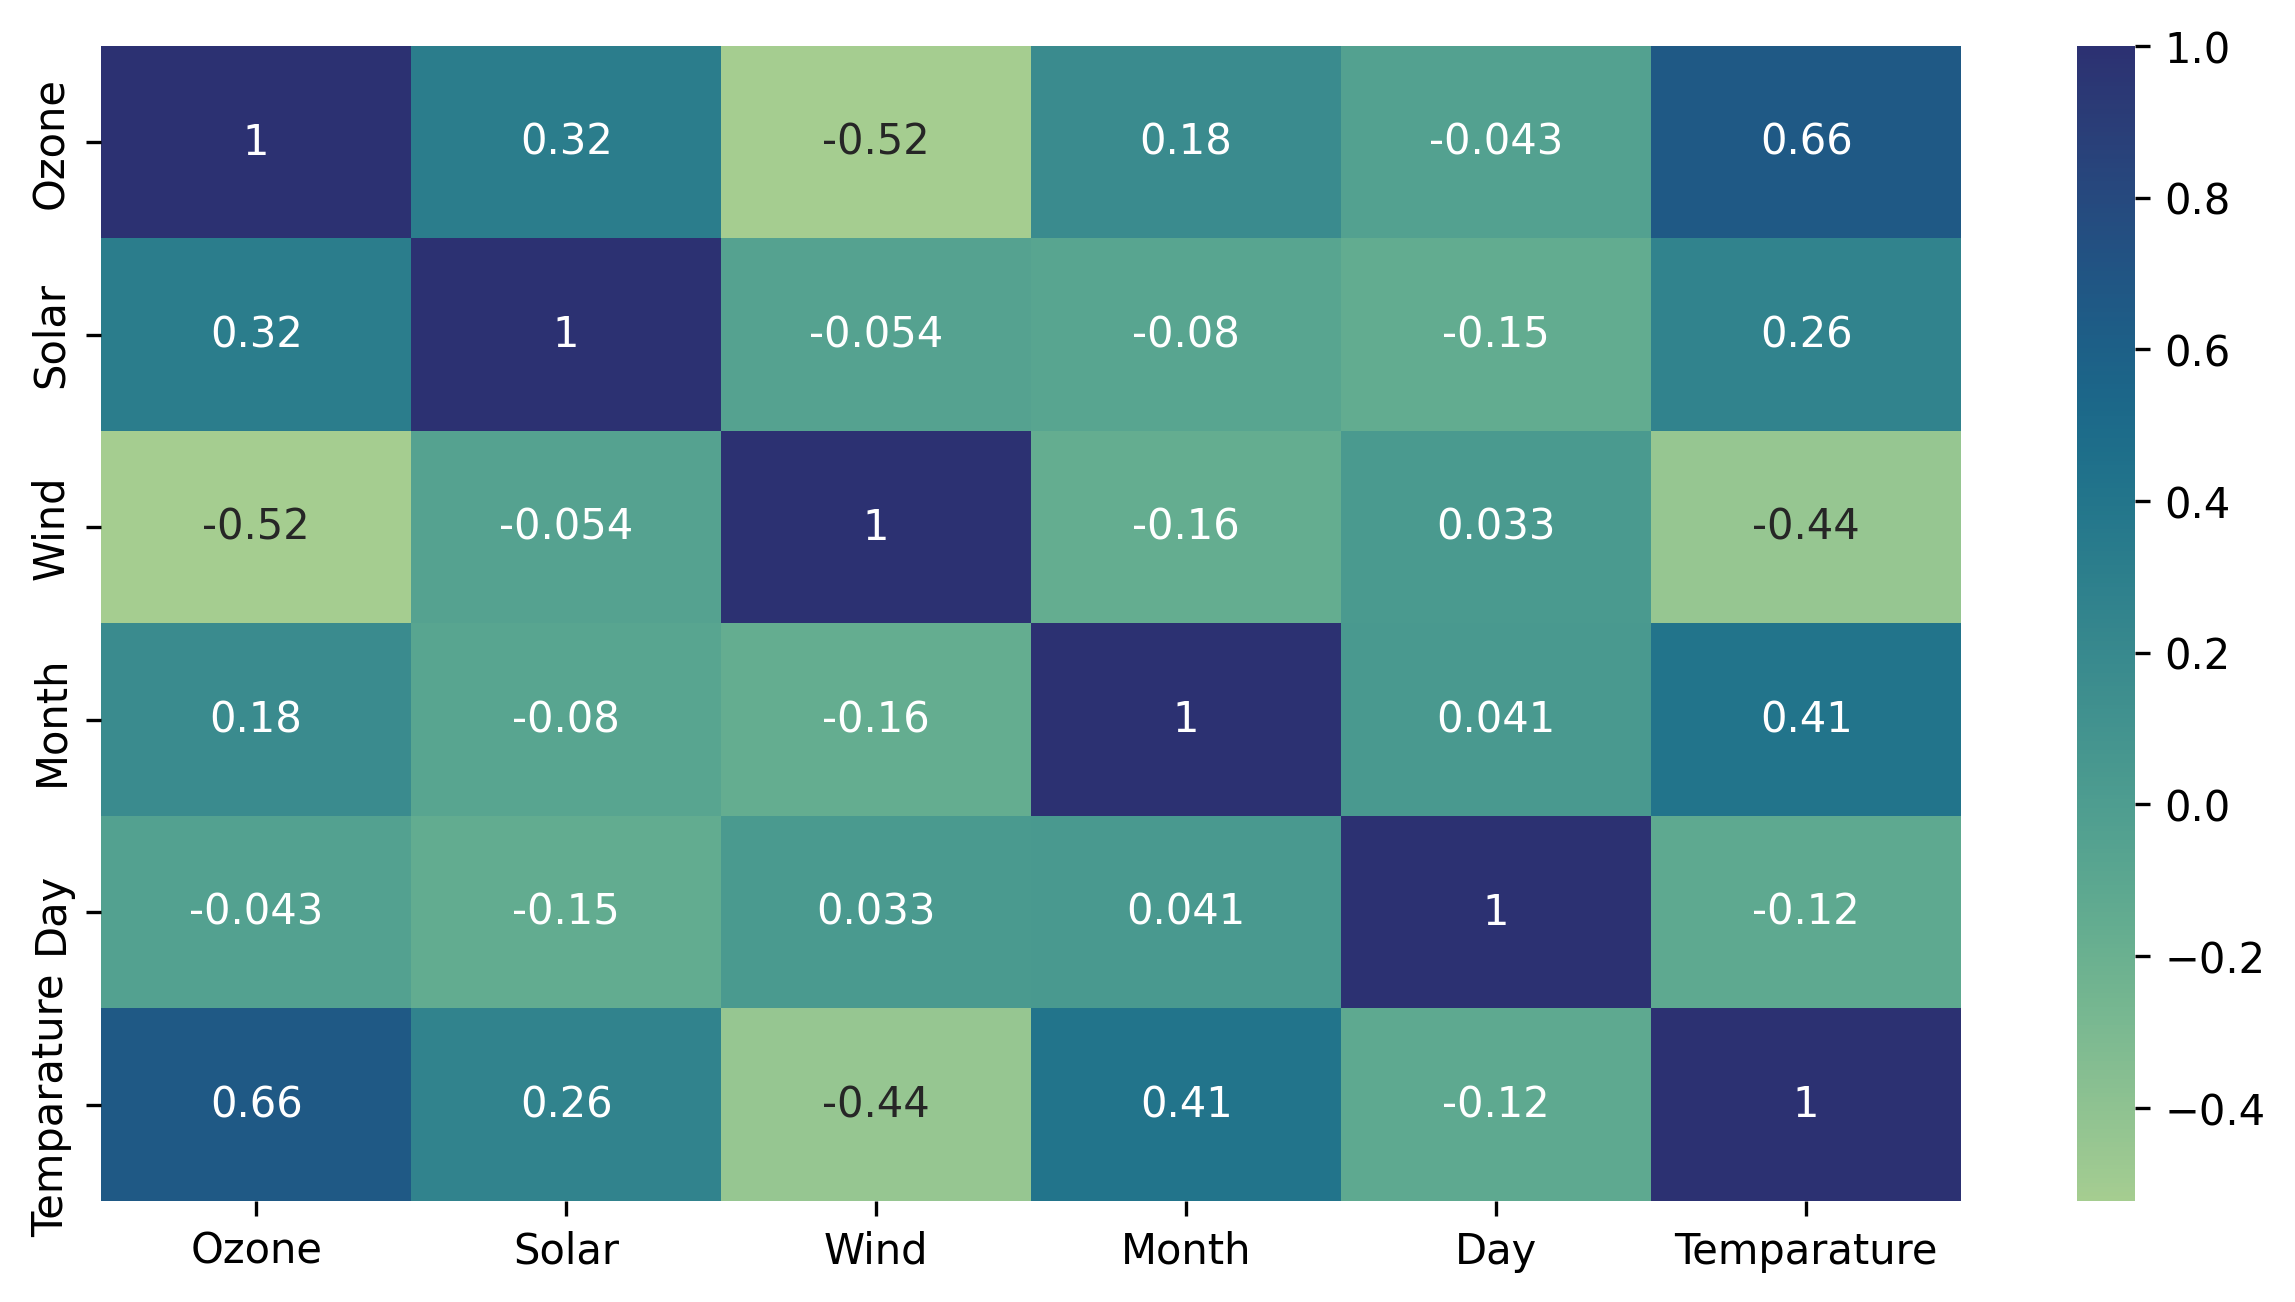

In [110]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="crest")

<Axes: >

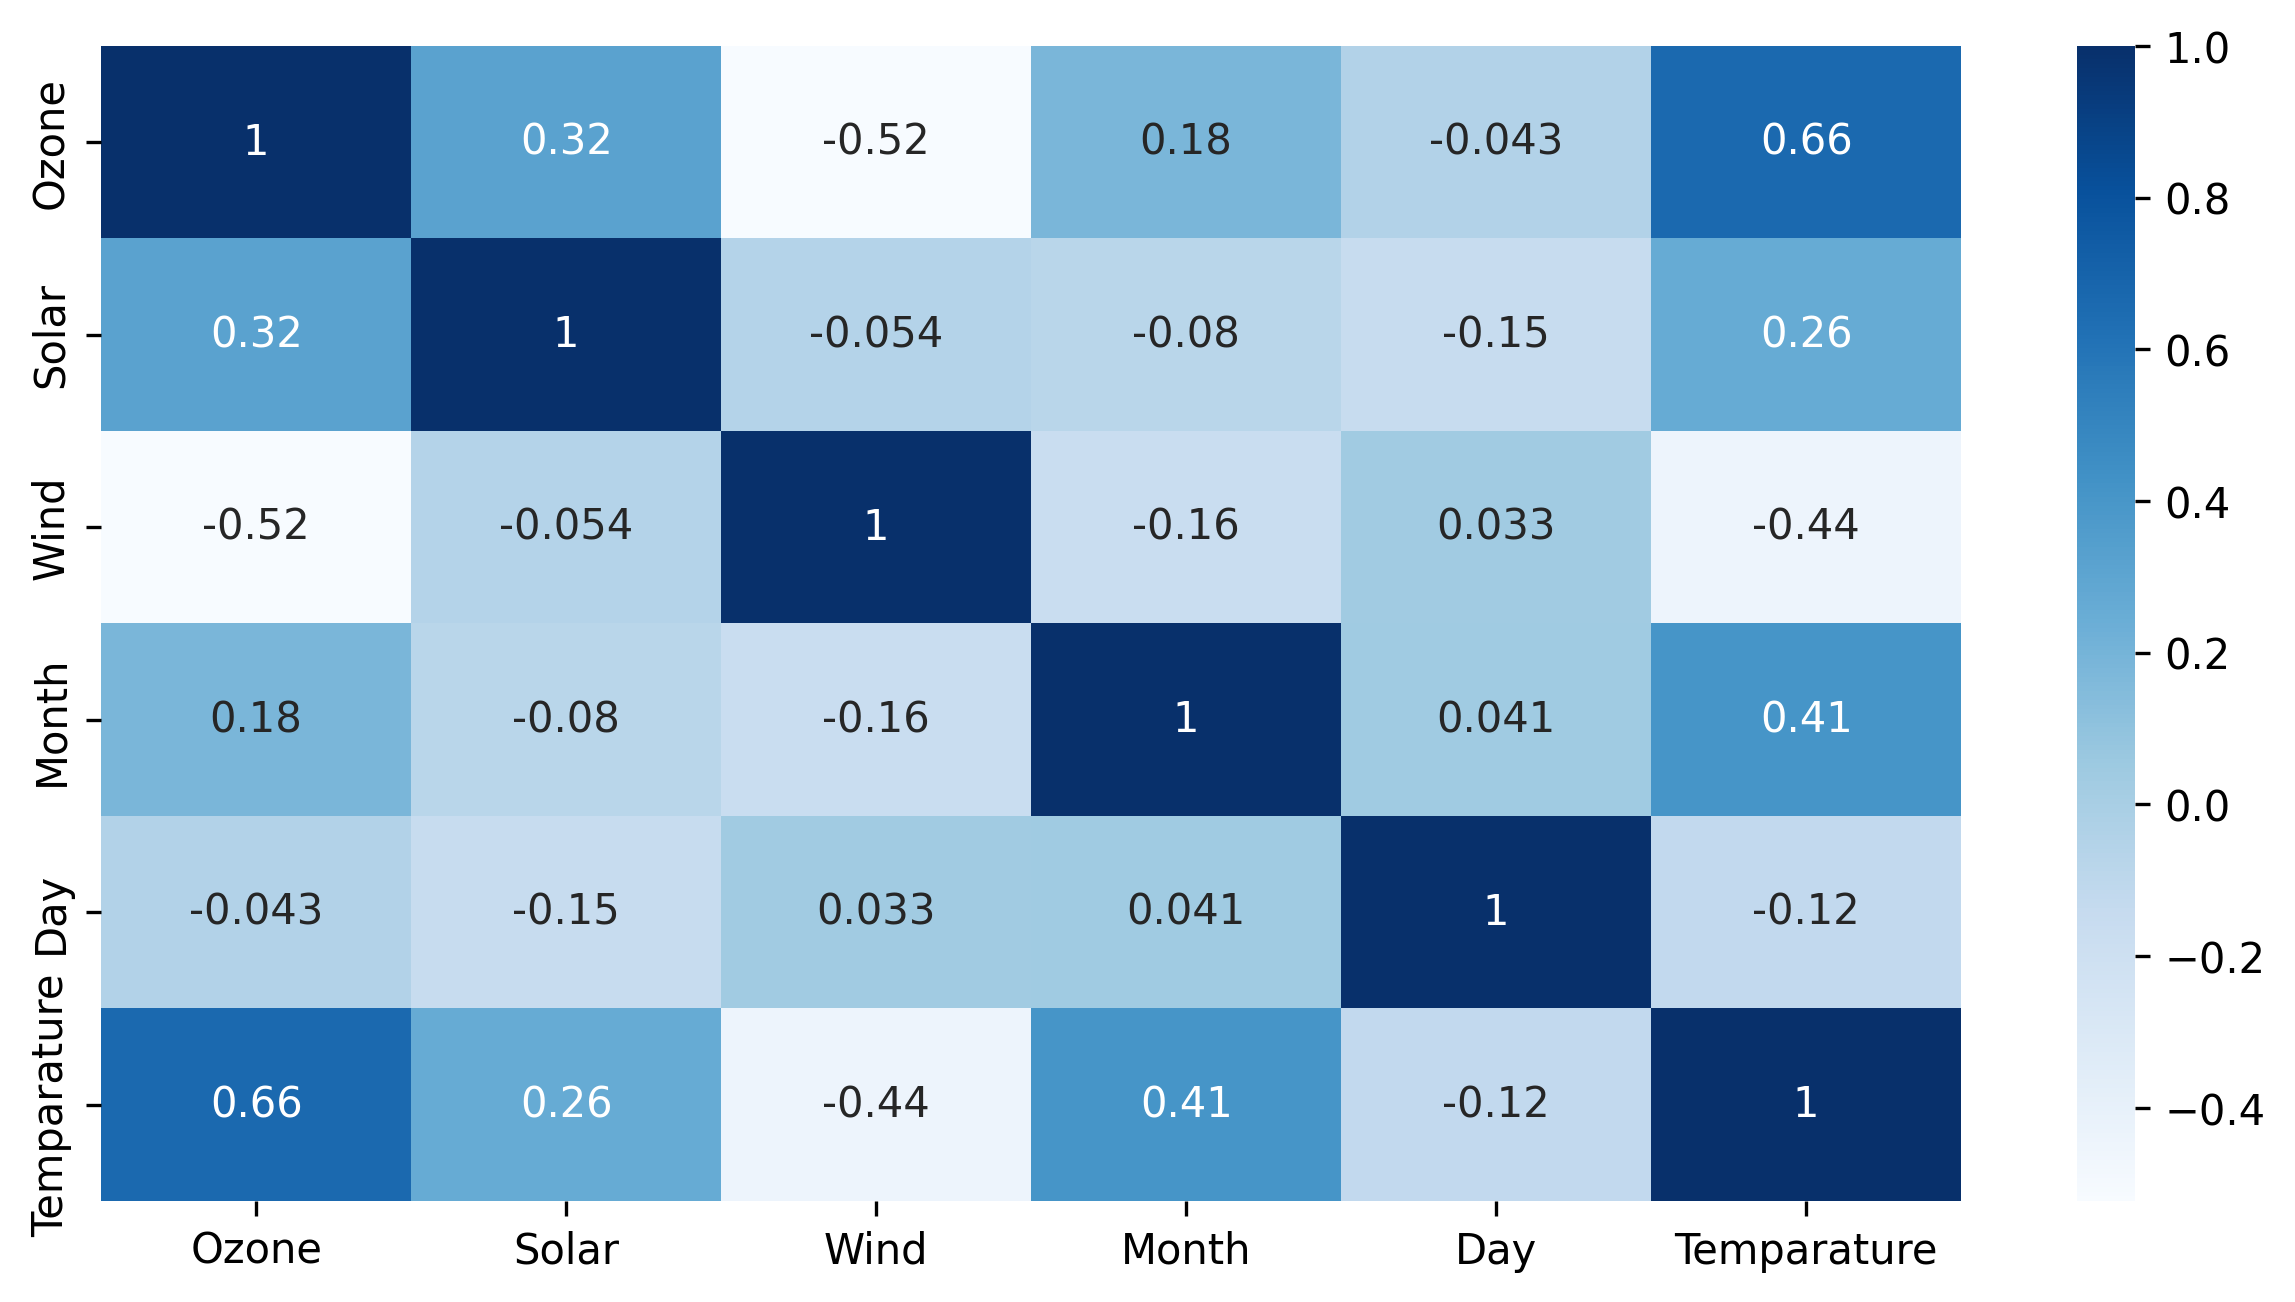

In [112]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")

# **Transformations**

*   Convert text data to numeric before model building



In [119]:
df.head()

,Ozone,Solar,Wind,Month,Day,Temparature,Weather_C,Weather_PS,Weather_S
0,41.0,190.000000,7.4,5,1,67,False,False,True
1,36.0,118.000000,8.0,5,2,72,True,False,False
2,12.0,149.000000,12.6,5,3,74,False,True,False
3,18.0,313.000000,11.5,5,4,62,False,False,True
4,31.0,185.366667,14.3,5,5,56,False,False,True


In [121]:
#Encoding using pandas dummy function
df = pd.get_dummies(data=df, columns=["Weather"])


KeyError: "None of [Index(['Weather'], dtype='object')] are in the [columns]"

In [122]:
df

,Ozone,Solar,Wind,Month,Day,Temparature,Weather_C,Weather_PS,Weather_S
0,41.0,190.000000,7.4,5,1,67,False,False,True
1,36.0,118.000000,8.0,5,2,72,True,False,False
2,12.0,149.000000,12.6,5,3,74,False,True,False
3,18.0,313.000000,11.5,5,4,62,False,False,True
4,31.0,185.366667,14.3,5,5,56,False,False,True
...,...,...,...,...,...,...,...,...,...
152,20.0,223.000000,11.5,9,30,68,False,False,True
153,41.0,190.000000,7.4,5,1,67,True,False,False
154,30.0,193.000000,6.9,9,26,70,False,True,False
155,31.0,145.000000,13.2,9,27,77,False,False,True


# **Scaling the data**


*   Bring down all columns to same scale
*   Normalization: scale value within the range 0 to 1
*   Standardization: uses Z score for scaling, scaling calues in such a way tha the mean=0 and std=1
*   List item





In [125]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [126]:
# Standardization
sc=StandardScaler() #Zscore=(x-xbr)/std

In [127]:
#sc.fit(): 1st mean andstd of ozone column is calculated.then in numerator subtraction os mean from the data points
#         then answer  is divided by std.thus z-score is calculated.
#sc.transform(): Original value in tablee is replaced by transform() function. i.e,41.0
#sc.fit_transform():does both of the above tasks

In [128]:
sc.fit_transform(df)

array([[ 0.19019358,  0.05342774, -0.73459309, ..., -0.67357531,
        -0.65366102,  1.2545001 ],
       [-0.03297826, -0.7768163 , -0.55759177, ...,  1.48461498,
        -0.65366102, -0.79713027],
       [-1.10420306, -0.41935011,  0.79941842, ..., -0.67357531,
         1.52984494, -0.79713027],
       ...,
       [-0.30078446,  0.08802124, -0.8820942 , ..., -0.67357531,
         1.52984494, -0.79713027],
       [-0.25615009, -0.46547478,  0.97641975, ..., -0.67357531,
        -0.65366102,  1.2545001 ],
       [-0.83639686, -0.62691113, -0.55759177, ...,  1.48461498,
        -0.65366102, -0.79713027]])

In [129]:
pd.DataFrame(sc.fit_transform(df))

,0,1,2,3,4,5,6,7,8
0,0.190194,0.053428,-0.734593,-1.412198,-1.668937,-1.146116,-0.673575,-0.653661,1.25450
1,-0.032978,-0.776816,-0.557592,-1.412198,-1.557152,-0.612802,1.484615,-0.653661,-0.79713
2,-1.104203,-0.419350,0.799418,-1.412198,-1.445367,-0.399476,-0.673575,1.529845,-0.79713
3,-0.836397,1.471761,0.474916,-1.412198,-1.333583,-1.679431,-0.673575,-0.653661,1.25450
4,-0.256150,0.000000,1.300922,-1.412198,-1.221798,-2.319408,-0.673575,-0.653661,1.25450
...,...,...,...,...,...,...,...,...,...
152,-0.747128,0.433956,0.474916,1.385469,1.572816,-1.039454,-0.673575,-0.653661,1.25450
153,0.190194,0.053428,-0.734593,-1.412198,-1.668937,-1.146116,1.484615,-0.653661,-0.79713
154,-0.300784,0.088021,-0.882094,1.385469,1.125678,-0.826128,-0.673575,1.529845,-0.79713
155,-0.256150,-0.465475,0.976420,1.385469,1.237462,-0.079488,-0.673575,-0.653661,1.25450


In [130]:
df.columns


Index(['Ozone', 'Solar', 'Wind', 'Month', 'Day', 'Temparature', 'Weather_C',
       'Weather_PS', 'Weather_S'],
      dtype='object')

In [133]:
scaled_data=pd.DataFrame(sc.fit_transform(df),columns=df.columns)
scaled_data

,Ozone,Solar,Wind,Month,Day,Temparature,Weather_C,Weather_PS,Weather_S
0,0.190194,0.053428,-0.734593,-1.412198,-1.668937,-1.146116,-0.673575,-0.653661,1.25450
1,-0.032978,-0.776816,-0.557592,-1.412198,-1.557152,-0.612802,1.484615,-0.653661,-0.79713
2,-1.104203,-0.419350,0.799418,-1.412198,-1.445367,-0.399476,-0.673575,1.529845,-0.79713
3,-0.836397,1.471761,0.474916,-1.412198,-1.333583,-1.679431,-0.673575,-0.653661,1.25450
4,-0.256150,0.000000,1.300922,-1.412198,-1.221798,-2.319408,-0.673575,-0.653661,1.25450
...,...,...,...,...,...,...,...,...,...
152,-0.747128,0.433956,0.474916,1.385469,1.572816,-1.039454,-0.673575,-0.653661,1.25450
153,0.190194,0.053428,-0.734593,-1.412198,-1.668937,-1.146116,1.484615,-0.653661,-0.79713
154,-0.300784,0.088021,-0.882094,1.385469,1.125678,-0.826128,-0.673575,1.529845,-0.79713
155,-0.256150,-0.465475,0.976420,1.385469,1.237462,-0.079488,-0.673575,-0.653661,1.25450


In [134]:
scaled_data.describe()

,Ozone,Solar,Wind,Month,Day,Temparature,Weather_C,Weather_PS,Weather_S
count,1.570000e+02,1.570000e+02,1.570000e+02,1.570000e+02,1.570000e+02,1.570000e+02,1.570000e+02,1.570000e+02,1.570000e+02
mean,-3.394312e-17,-9.051500e-17,1.470869e-16,1.810300e-16,-2.262875e-17,2.036587e-16,4.242891e-17,-8.485781e-18,-7.849347e-17
std,1.003200e+00,1.003200e+00,1.003200e+00,1.003200e+00,1.003200e+00,1.003200e+00,1.003200e+00,1.003200e+00,1.003200e+00
min,-1.595181e+00,-2.056776e+00,-2.416106e+00,-1.412198e+00,-1.668937e+00,-2.319408e+00,-6.735753e-01,-6.536610e-01,-7.971303e-01
25%,-7.024938e-01,-6.730358e-01,-7.345931e-01,-7.127815e-01,-8.864446e-01,-6.128020e-01,-6.735753e-01,-6.536610e-01,-7.971303e-01
50%,-2.561501e-01,8.802124e-02,-5.608800e-02,-1.336465e-02,7.832041e-03,1.338381e-01,-6.735753e-01,-6.536610e-01,-7.971303e-01
75%,3.687310e-01,8.029536e-01,4.749160e-01,6.860522e-01,9.021087e-01,6.671525e-01,1.484615e+00,1.529845e+00,1.254500e+00
max,1.975568e+00,1.713916e+00,2.289180e+00,1.385469e+00,1.684601e+00,2.053770e+00,1.484615e+00,1.529845e+00,1.254500e+00


In [135]:
#Normalization
mn=MinMaxScaler()

In [136]:
df.columns

Index(['Ozone', 'Solar', 'Wind', 'Month', 'Day', 'Temparature', 'Weather_C',
       'Weather_PS', 'Weather_S'],
      dtype='object')

In [137]:
minmax_scaled=pd.DataFrame(mn.fit_transform(df),columns=df.columns)
minmax_scaled

,Ozone,Solar,Wind,Month,Day,Temparature,Weather_C,Weather_PS,Weather_S
0,0.5000,0.559633,0.357367,0.0,0.000000,0.268293,0.0,0.0,1.0
1,0.4375,0.339450,0.394984,0.0,0.033333,0.390244,1.0,0.0,0.0
2,0.1375,0.434251,0.683386,0.0,0.066667,0.439024,0.0,1.0,0.0
3,0.2125,0.935780,0.614420,0.0,0.100000,0.146341,0.0,0.0,1.0
4,0.3750,0.545464,0.789969,0.0,0.133333,0.000000,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
152,0.2375,0.660550,0.614420,1.0,0.966667,0.292683,0.0,0.0,1.0
153,0.5000,0.559633,0.357367,0.0,0.000000,0.268293,1.0,0.0,0.0
154,0.3625,0.568807,0.326019,1.0,0.833333,0.341463,0.0,1.0,0.0
155,0.3750,0.422018,0.721003,1.0,0.866667,0.512195,0.0,0.0,1.0


In [138]:
minmax_scaled.describe()

,Ozone,Solar,Wind,Month,Day,Temparature,Weather_C,Weather_PS,Weather_S
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,0.446736,0.545464,0.513488,0.504777,0.497665,0.530371,0.312102,0.299363,0.388535
std,0.280949,0.266052,0.213207,0.358584,0.299147,0.229398,0.464834,0.459445,0.488977
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.366972,0.357367,0.250000,0.233333,0.390244,0.000000,0.000000,0.000000
50%,0.375000,0.568807,0.501567,0.500000,0.500000,0.560976,0.000000,0.000000,0.000000
75%,0.550000,0.758410,0.614420,0.750000,0.766667,0.682927,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# **Auto EDA**

In [2]:
!pip install pandas_profiling==3.1.0
!pip install -u ydata-profiling
!pip install sweetviz
!pip install --upgrade numba



Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -u


In [5]:
!pip install numba==0.56.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.6/34.6 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 51.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xgboost 2.1.1 requires nvidia-nccl-cu12; platform_system == "Linux" and platform_machine != "aarch64", which is not installed.

In [3]:
import pandas_profiling as pp
import ydata_profiling as yd
import sweetviz as sv
import pandas as pd

PydanticImportError: `BaseSettings` has been moved to the `pydantic-settings` package. See https://docs.pydantic.dev/2.8/migration/#basesettings-has-moved-to-pydantic-settings for more details.

For further information visit https://errors.pydantic.dev/2.8/u/import-error

In [6]:
import pandas as pd
df=pd.read_csv("/content/data_clean1.csv")
df.head()

,Ozone,Solar.R,Wind,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,5,1,2010,67,S
1,36.0,118.0,8.0,5,2,2010,72,C
2,12.0,149.0,12.6,5,3,2010,74,PS
3,18.0,313.0,11.5,5,4,2010,62,S
4,NaN,NaN,14.3,5,5,2010,56,S


In [7]:
EDA_report=pp.ProfileReport(df)
EDA_report

NameError: name 'pp' is not defined